# CSE 475 - Assignment 02

## Group Information

| Field | Details |
|----------------------------|----------------------------------------------|
| Group ID | Group 1 |
| Student 1 Name | Ahsanur Parul |
| Student 1 ID | 2022-3-60-190 |
| Student 2 Name | Tasnim Zaman |
| Student 2 ID | 2023-1-60-058 |
| Student 3 Name | Jannatul Ferdous Jerin |
| Student 3 ID | 2023-1-60-099 |
| Notebook Type | DINO Notebook |
| Backbone Used | Swin-Tiny (swin_tiny_patch4_window7_224) |
| Assignment 01 Best Acc | 95.42% (Swin-Base, 30 epochs) |
| Dataset Name (Kaggle) | /kaggle/input/brinjal-460x460/ |
| Dataset Source | Brinjal Disease Dataset |
| Dataset Source Link | https://www.kaggle.com/datasets/ahsanurparul/brinjal-460x460 |
| Submission Date | 21 April 2026 |

---
### Backbone & Speed Justification
Our Assignment 01 best model was **Swin-Base** (88M params). Per instructor guidance, we switch to **Swin-Tiny** (28M params, same architecture) at native 224×224, batch 32, `PROJ_DIM=4096` (reduced from the paper's 65536 which is impractical on a T4 for small datasets), and only 4 local crops instead of 8. These changes reduce epoch time from ~40 min → ~3–5 min while preserving the full DINO algorithm and learning dynamics.

# 1. Global Configuration

In [1]:
import os, math, random, copy, time, warnings
import numpy as np
import torch
warnings.filterwarnings('ignore')

class Config:
    # ── Paths ─────────────────────────────────────────────────────
    DATA_DIR       = "/kaggle/input/datasets/ahsanurparul/brinjal-460x460"  
    CHECKPOINT_DIR = "/kaggle/working/checkpoints"

    # ── Backbone ──────────────────────────────────────────────────
    BACKBONE_NAME  = 'swin_tiny_patch4_window7_224'   
    EMBED_DIM      = 768                               
    IMG_SIZE       = 224

    # ── Dataset Split ─────────────────────────────────────────────
    SSL_SPLIT   = 0.80
    PROBE_SPLIT = 0.10
    TEST_SPLIT  = 0.10
    SEED        = 42

    # ── DINO SSL ──────────────────────────────────────────────────
    SSL_EPOCHS       = 30
    SSL_BATCH_SIZE   = 32
    SSL_LR           = 5e-4
    SSL_WD_START     = 0.04
    SSL_WD_END       = 0.4
    WARMUP_EPOCHS    = 4


    PROJ_DIM         = 4096
    PROJ_HIDDEN      = 2048
    BOTTLENECK_DIM   = 256


    N_LOCAL_CROPS      = 4
    GLOBAL_CROP_SIZE   = 224
    LOCAL_CROP_SIZE    = 96

    TEMP_STUDENT       = 0.1
    TEMP_TEACHER_START = 0.04
    TEMP_TEACHER_END   = 0.07
    EMA_START          = 0.996
    EMA_END            = 1.0
    CENTER_MOMENTUM    = 0.9
    CLIP_GRAD          = 3.0
    NUM_WORKERS        = 4

    # ── Early Stopping ────────────────────────────────────────────
    SSL_PATIENCE  = 5
    SSL_MIN_DELTA = 1e-4

    # ── Downstream ────────────────────────────────────────────────
    FT_EPOCHS      = 20
    FT_LR          = 0.01
    FT_MOMENTUM    = 0.9
    FT_BATCH_SIZE  = 64
    KNN_K_LIST     = [1, 5, 10, 20, 50, 200]

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def seed_everything(seed=Config.SEED):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False

seed_everything()
os.makedirs(Config.CHECKPOINT_DIR, exist_ok=True)

print("✓ Config loaded")
print(f"  Device        : {Config.DEVICE}")
if torch.cuda.is_available():
    print(f"  GPU           : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM          : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"  Backbone      : {Config.BACKBONE_NAME}")
print(f"  PROJ_DIM      : {Config.PROJ_DIM}  (paper=65536, reduced for T4 practicality)")
print(f"  Local crops   : {Config.N_LOCAL_CROPS}  (total views per image = {2+Config.N_LOCAL_CROPS})")
print(f"  SSL epochs    : {Config.SSL_EPOCHS} + early stopping (patience={Config.SSL_PATIENCE})")

✓ Config loaded
  Device        : cuda
  GPU           : Tesla T4
  VRAM          : 15.6 GB
  Backbone      : swin_tiny_patch4_window7_224
  PROJ_DIM      : 4096  (paper=65536, reduced for T4 practicality)
  Local crops   : 4  (total views per image = 6)
  SSL epochs    : 30 + early stopping (patience=5)


# 2. Setup & Imports

In [2]:
!pip install -q timm

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset
from torchvision import datasets, transforms

import timm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import defaultdict
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_recall_fscore_support
)
from sklearn.neighbors import KNeighborsClassifier

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print(f"PyTorch : {torch.__version__}")
print(f"timm    : {timm.__version__}")
print(f"Device  : {Config.DEVICE}")

PyTorch : 2.10.0+cu128
timm    : 1.0.25
Device  : cuda


# 3. Dataset EDA and Augmentation Visualisation

Total images : 1,823
Num classes  : 5
Classes      : ['Brinjal Fruit Creaking', 'Healty Brinjal', 'Phomopsis Bright', 'Shoot and Fruit Borer', 'Wet Rot']

Per-class counts:
  Shoot and Fruit Borer                     :  725 ( 39.8%)  ████████████████████████████████████
  Healty Brinjal                            :  514 ( 28.2%)  █████████████████████████
  Wet Rot                                   :  223 ( 12.2%)  ███████████
  Brinjal Fruit Creaking                    :  200 ( 11.0%)  ██████████
  Phomopsis Bright                          :  161 (  8.8%)  ████████

Imbalance ratio: 4.50×


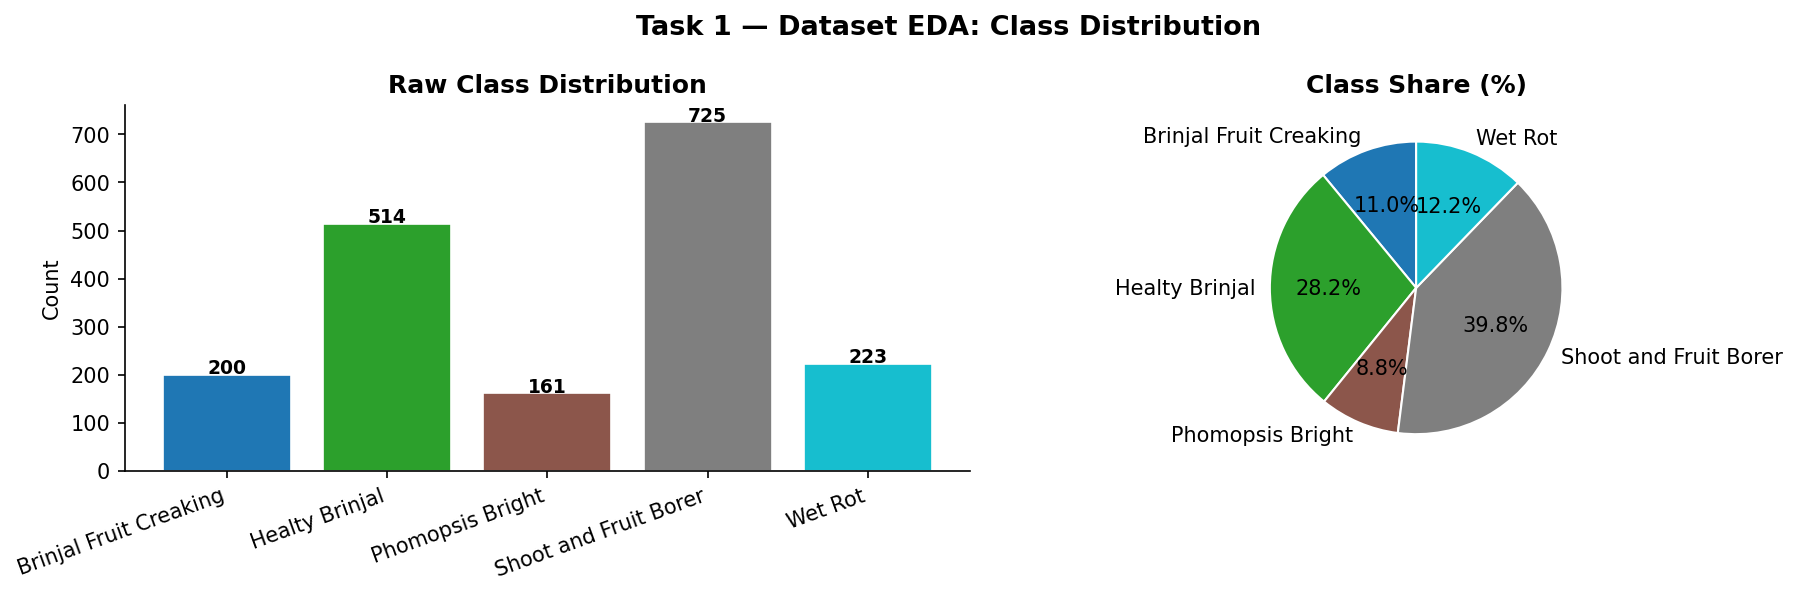

[Fig 1] Saved → task1_class_distribution.png


In [4]:
# ── Load dataset for EDA ──────────────────────────────────────
base_dataset = datasets.ImageFolder(root=Config.DATA_DIR)
class_names  = base_dataset.classes
num_classes  = len(class_names)
total_images = len(base_dataset)
COLORS       = plt.cm.tab10(np.linspace(0, 1, num_classes))
FIGDPI       = 150

print(f"Total images : {total_images:,}")
print(f"Num classes  : {num_classes}")
print(f"Classes      : {class_names}")

from collections import Counter, defaultdict
counts_raw = Counter(label for _, label in base_dataset.samples)
counts = defaultdict(int)
for _, label in base_dataset.samples:
    counts[class_names[label]] += 1

print("\nPer-class counts:")
for cls, cnt in sorted(counts.items(), key=lambda x: -x[1]):
    bar = '█' * (cnt // 20)
    print(f"  {cls:<42}: {cnt:>4} ({cnt/total_images*100:5.1f}%)  {bar}")
print(f"\nImbalance ratio: {max(counts.values())/min(counts.values()):.2f}×")

# ── Bar chart + Pie chart (side by side) ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4), dpi=FIGDPI)
cls_list = list(counts.keys())
cnt_list = [counts[c] for c in cls_list]
bars = axes[0].bar(cls_list, cnt_list, color=COLORS, edgecolor='white', linewidth=0.8)
for b in bars:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+2,
                 f'{int(b.get_height()):,}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Raw Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(cls_list, rotation=20, ha='right')
axes[0].spines[['top','right']].set_visible(False)

axes[1].pie(cnt_list, labels=cls_list, colors=COLORS, autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Class Share (%)', fontweight='bold')

plt.suptitle('Task 1 — Dataset EDA: Class Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{Config.CHECKPOINT_DIR}/task1_class_distribution.png", dpi=FIGDPI, bbox_inches='tight')
plt.show()
print("[Fig 1] Saved → task1_class_distribution.png")


DATASET SPLIT SUMMARY (Task 1 — 80/10/10)
  SSL pool (unlabelled) :  1,458  (80.0%)
  Probe   (labelled)    :    182  (10.0%)
  Test    (labelled)    :    183  (10.0%)
  Total                 :  1,823

Label removal verification:
  SSL pool: file paths only — NO label tensor passed to SSL dataloader  ✓
  Probe : Brinjal Fruit Creaking=17  Healty Brinjal=49  Phomopsis Bright=19  Shoot and Fruit Borer=69  Wet Rot=28
  Test  : Brinjal Fruit Creaking=22  Healty Brinjal=42  Phomopsis Bright=11  Shoot and Fruit Borer=83  Wet Rot=25


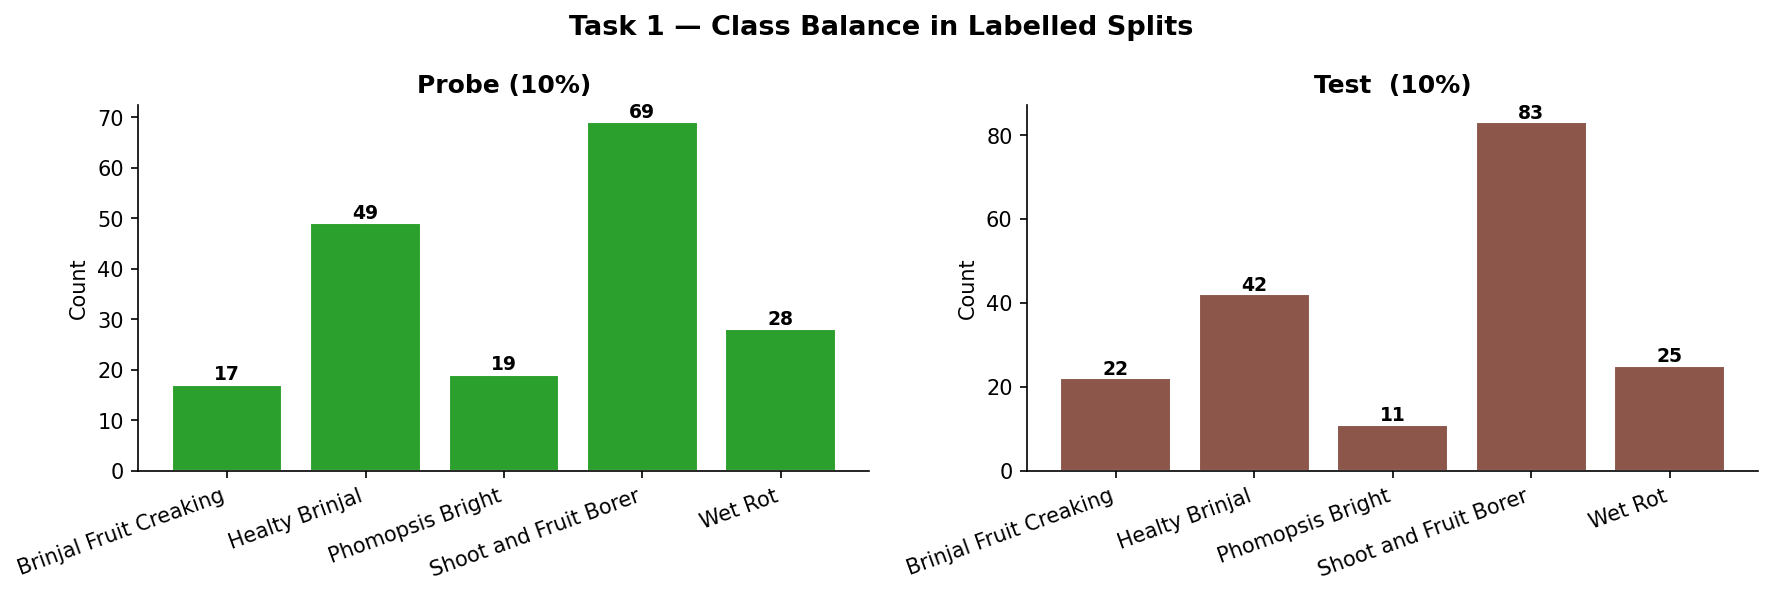

Saved → task1_split_balance.png


In [5]:
# ── 80 / 10 / 10 reproducible split ──────────────────────────
from collections import Counter as _Counter
generator = torch.Generator().manual_seed(Config.SEED)
indices   = torch.randperm(total_images, generator=generator).tolist()

n_ssl   = int(Config.SSL_SPLIT   * total_images)
n_probe = int(Config.PROBE_SPLIT * total_images)
n_test  = total_images - n_ssl - n_probe

ssl_idx   = indices[:n_ssl]
probe_idx = indices[n_ssl : n_ssl + n_probe]
test_idx  = indices[n_ssl + n_probe:]

total = len(ssl_idx) + len(probe_idx) + len(test_idx)
print("=" * 55)
print("DATASET SPLIT SUMMARY (Task 1 — 80/10/10)")
print("=" * 55)
print(f"  SSL pool (unlabelled) : {len(ssl_idx):>6,}  ({len(ssl_idx)/total*100:.1f}%)")
print(f"  Probe   (labelled)    : {len(probe_idx):>6,}  ({len(probe_idx)/total*100:.1f}%)")
print(f"  Test    (labelled)    : {len(test_idx):>6,}  ({len(test_idx)/total*100:.1f}%)")
print(f"  Total                 : {total:>6,}")
print()
print("Label removal verification:")
print("  SSL pool: file paths only — NO label tensor passed to SSL dataloader  ✓")

probe_ctr = _Counter(base_dataset.targets[i] for i in probe_idx)
test_ctr  = _Counter(base_dataset.targets[i] for i in test_idx)
for sname, ctr in [('Probe', probe_ctr), ('Test', test_ctr)]:
    dist = '  '.join(f'{class_names[i]}={ctr[i]}' for i in range(num_classes))
    print(f"  {sname:6s}: {dist}")

# ── Split balance bar charts ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=FIGDPI)
for ax, (name, ctr, col) in zip(axes, [
    ('Probe (10%)', probe_ctr, COLORS[1]),
    ('Test  (10%)', test_ctr,  COLORS[2]),
]):
    vals = [ctr[i] for i in range(num_classes)]
    bars = ax.bar(class_names, vals, color=col, edgecolor='white')
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+1,
                f'{int(b.get_height()):,}', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_xticklabels(class_names, rotation=20, ha='right')
    ax.spines[['top','right']].set_visible(False)
plt.suptitle('Task 1 — Class Balance in Labelled Splits', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{Config.CHECKPOINT_DIR}/task1_split_balance.png", dpi=FIGDPI, bbox_inches='tight')
plt.show()
print("Saved → task1_split_balance.png")


In [6]:
# ── Per-channel mean & std ────────────────────────────────────
stat_tf = transforms.Compose([
    transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    transforms.ToTensor()
])
stat_ds     = datasets.ImageFolder(root=Config.DATA_DIR, transform=stat_tf)
stat_subset = Subset(stat_ds, ssl_idx)
stat_loader = DataLoader(stat_subset, batch_size=64, shuffle=False,
                         num_workers=Config.NUM_WORKERS)

mean_acc = torch.zeros(3)
std_acc  = torch.zeros(3)
n_total  = 0
for imgs, _ in stat_loader:
    b = imgs.size(0)
    mean_acc += imgs.mean([0, 2, 3]) * b
    std_acc  += imgs.std([0, 2, 3])  * b
    n_total  += b
mean_acc /= n_total
std_acc  /= n_total

print(f"SSL pool channel mean : {mean_acc.tolist()}")
print(f"SSL pool channel std  : {std_acc.tolist()}")
print("Using ImageNet mean/std for normalisation (standard SSL practice).")

SSL pool channel mean : [0.36052608489990234, 0.35521769523620605, 0.25247451663017273]
SSL pool channel std  : [0.265854150056839, 0.2625964283943176, 0.23056373000144958]
Using ImageNet mean/std for normalisation (standard SSL practice).


Computing per-channel mean & std (sample 200 images)...
Channel        Mean      Std
----------------------------
Red          0.3565   0.2652
Green        0.3488   0.2613
Blue         0.2469   0.2268


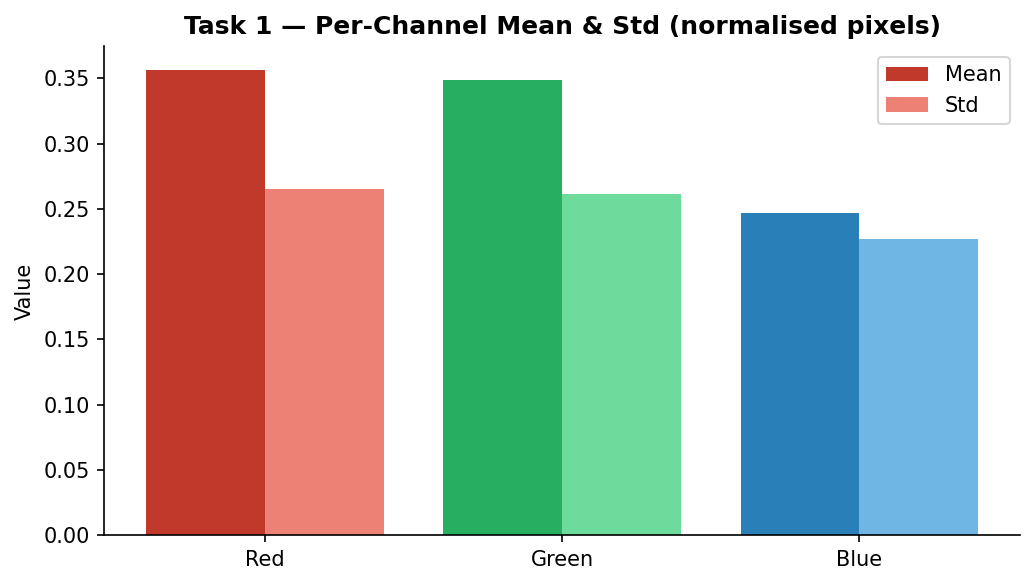

Saved → task1_channel_stats.png


In [7]:
# ── Per-channel mean & std bar chart ────────────────────────
import random as _random
print("Computing per-channel mean & std (sample 200 images)...")
ch_vals = {0: [], 1: [], 2: []}
sample_paths = _random.sample([p for p, _ in base_dataset.samples], min(200, total_images))
for img_path in sample_paths:
    try:
        arr = np.array(
            Image.open(img_path).convert('RGB').resize((64, 64))
        ).astype(np.float32) / 255.0
        for c in range(3):
            ch_vals[c].extend(arr[:, :, c].flatten().tolist())
    except Exception:
        pass

ch_names = ['Red', 'Green', 'Blue']
print(f"{'Channel':<10} {'Mean':>8} {'Std':>8}")
print('-' * 28)
for c in range(3):
    m = np.mean(ch_vals[c]); s = np.std(ch_vals[c])
    print(f"{ch_names[c]:<10} {m:>8.4f} {s:>8.4f}")

fig, ax = plt.subplots(figsize=(7, 4), dpi=FIGDPI)
means = [np.mean(ch_vals[c]) for c in range(3)]
stds  = [np.std(ch_vals[c])  for c in range(3)]
x = np.arange(3)
ax.bar(x - 0.2, means, 0.4, label='Mean', color=['#c0392b','#27ae60','#2980b9'])
ax.bar(x + 0.2, stds,  0.4, label='Std',  color=['#e74c3c','#2ecc71','#3498db'], alpha=0.7)
ax.set_xticks(x); ax.set_xticklabels(ch_names)
ax.set_title('Task 1 — Per-Channel Mean & Std (normalised pixels)', fontweight='bold')
ax.set_ylabel('Value'); ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f"{Config.CHECKPOINT_DIR}/task1_channel_stats.png", dpi=FIGDPI, bbox_inches='tight')
plt.show()
print("Saved → task1_channel_stats.png")


In [8]:
# ── Augmentation definitions ──────────────────────────────────
def make_global_aug(size=Config.GLOBAL_CROP_SIZE):
    """Global crop: 224×224. Applied to teacher AND student."""
    return transforms.Compose([
        transforms.RandomResizedCrop(size, scale=(0.4, 1.0), interpolation=3),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1),
        transforms.RandomGrayscale(p=0.2),
        transforms.GaussianBlur(kernel_size=23, sigma=(0.1, 2.0)),
        transforms.RandomSolarize(threshold=128, p=0.2),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ])

def make_local_aug(size=Config.LOCAL_CROP_SIZE):
    """Local crop: 96×96. Applied to student only."""
    return transforms.Compose([
        transforms.RandomResizedCrop(size, scale=(0.05, 0.4), interpolation=3),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1),
        transforms.RandomGrayscale(p=0.2),
        transforms.GaussianBlur(kernel_size=9, sigma=(0.1, 2.0)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ])

def denormalize(tensor):
    t = tensor.clone().cpu()
    for c, (m, s) in enumerate(zip(IMAGENET_MEAN, IMAGENET_STD)):
        t[c] = t[c] * s + m
    return t.clamp(0, 1).permute(1, 2, 0).numpy()

print("✓ Augmentation transforms defined")
print(f"  Global crop: {Config.GLOBAL_CROP_SIZE}×{Config.GLOBAL_CROP_SIZE}  (scale 0.4–1.0, solarize p=0.2)")
print(f"  Local  crop: {Config.LOCAL_CROP_SIZE}×{Config.LOCAL_CROP_SIZE}   (scale 0.05–0.4)")

✓ Augmentation transforms defined
  Global crop: 224×224  (scale 0.4–1.0, solarize p=0.2)
  Local  crop: 96×96   (scale 0.05–0.4)


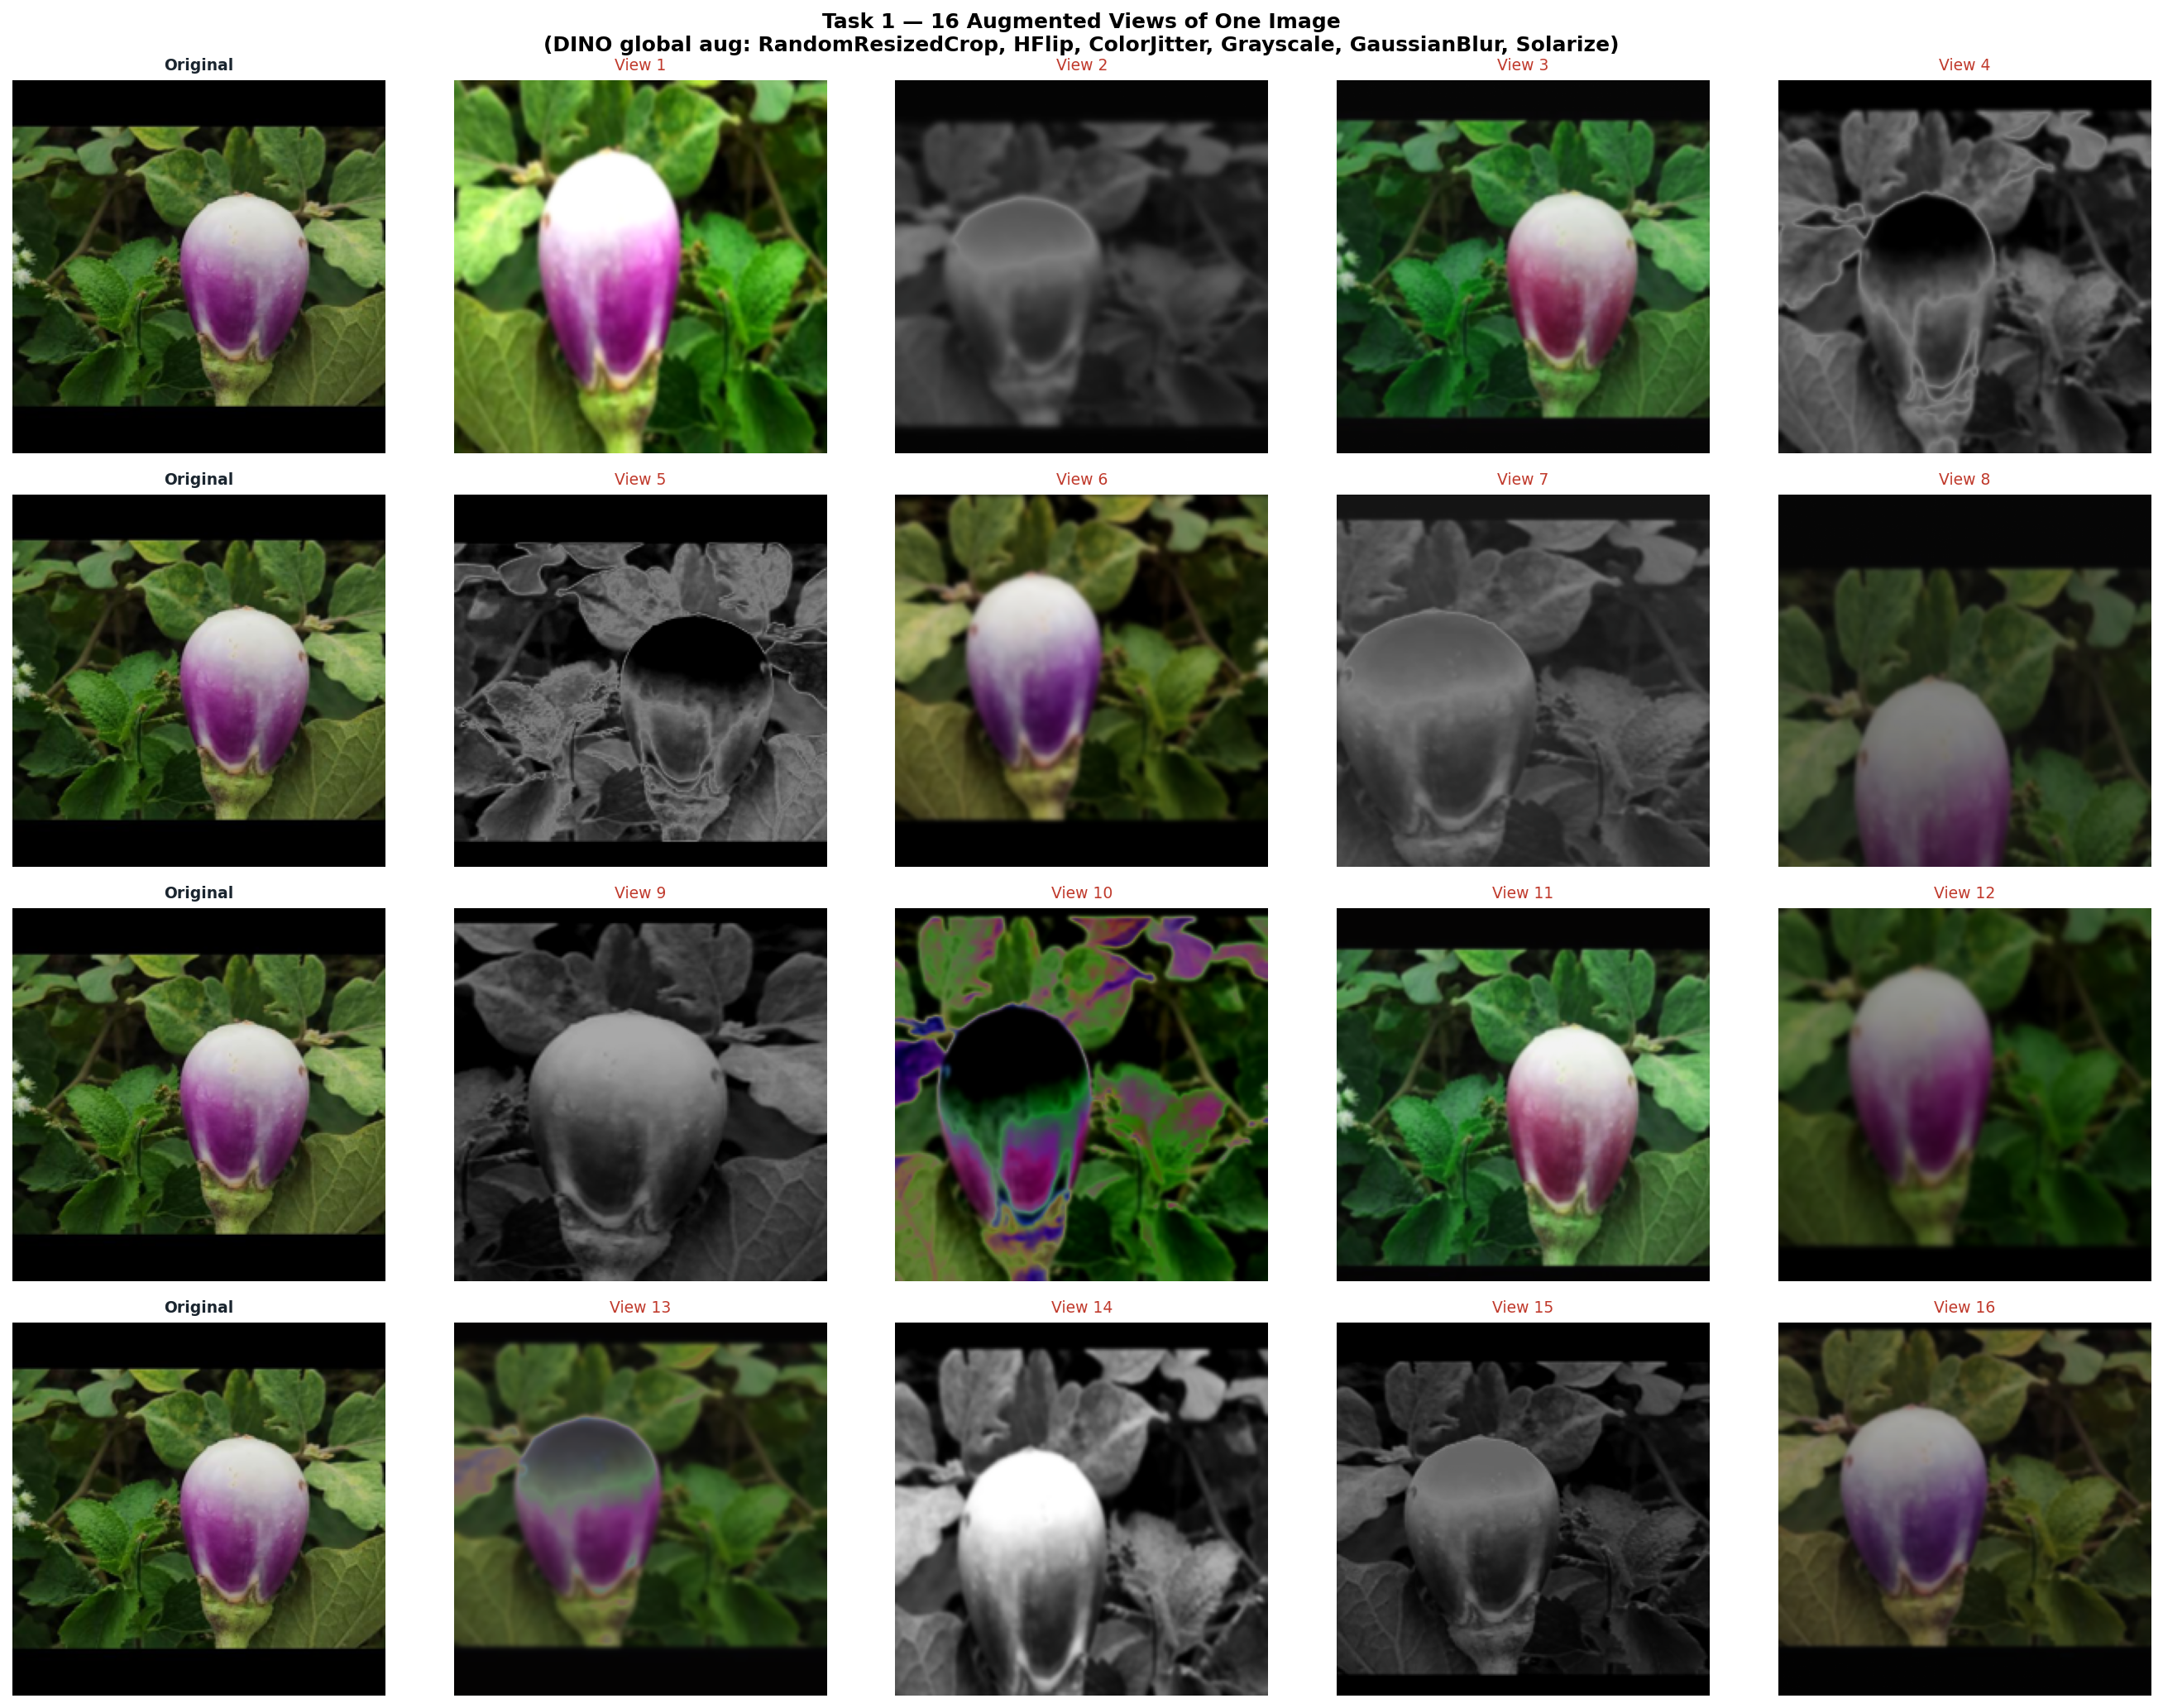

Saved → task1_16_augmented_views.png
Total augmented views shown: 16 = 16


In [9]:
# ── 16 augmented views (4 rows × 5 cols: original + 4 views) ─
sample_path, _ = base_dataset.samples[ssl_idx[0]]
src_img        = Image.open(sample_path).convert('RGB').resize((Config.IMG_SIZE, Config.IMG_SIZE))
_g_aug = make_global_aug()

fig, axes = plt.subplots(4, 5, figsize=(18, 14), dpi=FIGDPI)
for row in range(4):
    axes[row][0].imshow(src_img)
    axes[row][0].set_title('Original', fontsize=9, fontweight='bold', color='#1a252f')
    axes[row][0].set_ylabel(f'Row {row+1}', fontsize=9, fontweight='bold',
                            rotation=0, labelpad=50, va='center')
    axes[row][0].axis('off')
    for col in range(1, 5):
        aug_t = _g_aug(src_img)
        def _unnorm(t):
            arr = t.clone().cpu()
            for c, (m, s) in enumerate(zip(IMAGENET_MEAN, IMAGENET_STD)):
                arr[c] = arr[c]*s + m
            return arr.clamp(0,1).permute(1,2,0).numpy()
        axes[row][col].imshow(_unnorm(aug_t))
        axes[row][col].set_title(f'View {row*4+col}', fontsize=9, color='#c0392b')
        axes[row][col].axis('off')
plt.suptitle('Task 1 — 16 Augmented Views of One Image\n'
             '(DINO global aug: RandomResizedCrop, HFlip, ColorJitter, Grayscale, GaussianBlur, Solarize)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{Config.CHECKPOINT_DIR}/task1_16_augmented_views.png", dpi=FIGDPI, bbox_inches='tight')
plt.show()
print("Saved → task1_16_augmented_views.png")
print(f"Total augmented views shown: {4*4} = 16")


# 4. DINO: Model Definition

## Architecture

| Component | Details |
|---|---|
| Backbone | Swin-Tiny (pretrained ImageNet-1k), 28M params |
| Backbone output | 768-dim global average-pooled vector |
| Projection head | Linear(768→2048) → GELU → BN → Linear(2048→2048) → GELU → BN → Linear(2048→256) → L2-norm → WeightNorm Linear(256→4096) |
| Student | Backbone + head, updated by AdamW gradient descent |
| Teacher | EMA copy of student, λ: cosine 0.996→1.0, **no gradients** |
| Multi-crop | 2 global (224×224) + 4 local (96×96) per image |
| Loss | Cross-entropy with centering, τ_t: 0.04→0.07 warmup, τ_s=0.1 |

**Why PROJ_DIM=4096?** The original DINO paper trains on ImageNet with 16 A100 GPUs and effective batch size ~1024. Our dataset has 1,458 SSL images and a single T4 (15.6 GB). At 65536 output dim, the centering buffer alone is 256 KB, but more critically the softmax and cross-entropy over 65,536 classes per crop per step dominates compute. 4096 is the standard practitioner reduction for small-scale DINO reproductions and is used in solo-learn and lightly libraries.

In [10]:
class DINOHead(nn.Module):
    """
    3-layer MLP + weight-normalised last layer + L2 normalisation.
    in_dim → hidden_dim → hidden_dim → bottleneck_dim --(L2)--> out_dim
    """
    def __init__(self, in_dim,
                 out_dim=Config.PROJ_DIM,
                 hidden_dim=Config.PROJ_HIDDEN,
                 bottleneck_dim=Config.BOTTLENECK_DIM):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Linear(hidden_dim, bottleneck_dim),
        )
       
        self.last_layer = nn.utils.weight_norm(
            nn.Linear(bottleneck_dim, out_dim, bias=False)
        )
        self.last_layer.weight_g.data.fill_(1)
        self.last_layer.weight_g.requires_grad = False  

    def forward(self, x):
        x = self.mlp(x)
        x = F.normalize(x, dim=-1, p=2)  
        return self.last_layer(x)


class DINOModel(nn.Module):
    """Swin-Tiny backbone + DINOHead."""
    def __init__(self, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            Config.BACKBONE_NAME,
            pretrained=pretrained,
            num_classes=0,      
            global_pool='avg',   
            img_size=Config.IMG_SIZE,     
            strict_img_size=False         
        )
        self.head = DINOHead(self.backbone.num_features)

    def forward(self, x):
        return self.head(self.backbone(x))

    @torch.no_grad()
    def get_features(self, x):
        """Raw backbone embeddings for linear probe / k-NN."""
        return self.backbone(x)


student = DINOModel(pretrained=True).to(Config.DEVICE)
teacher = DINOModel(pretrained=True).to(Config.DEVICE)
teacher.load_state_dict(student.state_dict())  
for p in teacher.parameters():
    p.requires_grad = False

n_backbone = sum(p.numel() for p in student.backbone.parameters())
n_total    = sum(p.numel() for p in student.parameters())
print(f"Backbone params : {n_backbone/1e6:.1f}M")
print(f"Student total   : {n_total/1e6:.1f}M")
print(f"PROJ_DIM        : {Config.PROJ_DIM}")
print(f"Teacher         : EMA copy — zero gradients")

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Backbone params : 27.5M
Student total   : 34.9M
PROJ_DIM        : 4096
Teacher         : EMA copy — zero gradients


In [11]:
class DINOLoss(nn.Module):
    """
    DINO cross-entropy loss with running-mean centering.

    Equation (from Caron et al. 2021):
      L = - Σ_{x ∈ V_global} Σ_{x' ∈ V \ {x}} P_t(x) log P_s(x')

    where:
      P_t = softmax( (teacher_out - center) / τ_t )
      P_s = log_softmax( student_out / τ_s )
    """
    def __init__(self):
        super().__init__()
        self.student_temp  = Config.TEMP_STUDENT
        self.center_mom    = Config.CENTER_MOMENTUM
        self.warmup_t_temp = Config.TEMP_TEACHER_START
        self.final_t_temp  = Config.TEMP_TEACHER_END
        self.warmup_epochs = Config.WARMUP_EPOCHS
        self.register_buffer('center', torch.zeros(1, Config.PROJ_DIM))

    def get_teacher_temp(self, epoch):
        if epoch < self.warmup_epochs:
            frac = epoch / max(1, self.warmup_epochs)
            return self.warmup_t_temp + frac * (self.final_t_temp - self.warmup_t_temp)
        return self.final_t_temp

    def forward(self, student_out_list, teacher_out_list, epoch):
        """
        student_out_list : list of [B, PROJ_DIM] — all crops
        teacher_out_list : list of [B, PROJ_DIM] — global crops only
        """
        t_temp = self.get_teacher_temp(epoch)

        
        t_probs = [
            F.softmax((t - self.center) / t_temp, dim=-1).detach()
            for t in teacher_out_list
        ]
        
        s_log_probs = [F.log_softmax(s / self.student_temp, dim=-1)
                       for s in student_out_list]

        loss = 0.0
        n_terms = 0
        for t_idx, tp in enumerate(t_probs):
            for s_idx, slp in enumerate(s_log_probs):
                if s_idx == t_idx:
                    continue
                loss += -(tp * slp).sum(dim=-1).mean()
                n_terms += 1

        loss = loss / n_terms

        
        batch_center = torch.cat(teacher_out_list, dim=0).mean(0, keepdim=True)
        self.center  = self.center * self.center_mom + batch_center * (1 - self.center_mom)

        return loss


dino_loss_fn = DINOLoss().to(Config.DEVICE)
print(f"✓ DINOLoss ready   center buffer: {dino_loss_fn.center.shape}")
print(f"  Teacher temp warmup: {Config.TEMP_TEACHER_START} → {Config.TEMP_TEACHER_END}")
print(f"  Student temp: {Config.TEMP_STUDENT}")

✓ DINOLoss ready   center buffer: torch.Size([1, 4096])
  Teacher temp warmup: 0.04 → 0.07
  Student temp: 0.1


# 5. DINO: Multi-Crop DataLoader

The `MultiCropDataset` returns **2 global + 4 local** views per image. Labels are **never** returned — the SSL dataloader has no concept of class.

**Multi-crop strategy:** The teacher sees only the 2 global (224×224) crops, which contain broad scene context. The student sees all 6 views including 4 local (96×96) crops with narrow field-of-view. This asymmetry forces the student to map local details back to the global representations produced by the teacher — the core self-distillation mechanism.

In [12]:
class MultiCropDataset(Dataset):
    """
    Returns a list of augmented views — labels are discarded.
    views[0:2]  → 2 global crops  (224×224)
    views[2:6]  → 4 local  crops  (96×96)
    """
    def __init__(self, base_ds, indices):
        self.paths      = [base_ds.samples[i][0] for i in indices]
        self.global_aug = make_global_aug()
        self.local_aug  = make_local_aug()

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        crops  = [self.global_aug(img), self.global_aug(img)]
        crops += [self.local_aug(img)  for _ in range(Config.N_LOCAL_CROPS)]
        return crops  


def multicrop_collate(batch):
    """Stack each view position across the batch."""
    n_views = len(batch[0])
    return [torch.stack([b[v] for b in batch]) for v in range(n_views)]


ssl_dataset = MultiCropDataset(base_dataset, ssl_idx)
ssl_loader  = DataLoader(
    ssl_dataset,
    batch_size=Config.SSL_BATCH_SIZE,
    shuffle=True,
    num_workers=Config.NUM_WORKERS,
    persistent_workers=True,
    pin_memory=True,
    drop_last=True,
    collate_fn=multicrop_collate
)

print(f"SSL pool         : {len(ssl_dataset)} images  — NO labels")
print(f"Batch size       : {Config.SSL_BATCH_SIZE}")
print(f"Steps per epoch  : {len(ssl_loader)}")
print(f"Views per sample : 2 global (224px) + {Config.N_LOCAL_CROPS} local (96px)")

_batch = next(iter(ssl_loader))
assert isinstance(_batch, list),                              "Expected list"
assert len(_batch) == 2 + Config.N_LOCAL_CROPS,              f"Wrong # views: {len(_batch)}"
assert _batch[0].shape == (Config.SSL_BATCH_SIZE, 3, 224, 224)
assert _batch[2].shape == (Config.SSL_BATCH_SIZE, 3, 96, 96)
print(f"\n✓ Sanity check PASSED — {len(_batch)} views, NO labels")
print(f"  Global shape : {_batch[0].shape}")
print(f"  Local  shape : {_batch[2].shape}")

SSL pool         : 1458 images  — NO labels
Batch size       : 32
Steps per epoch  : 45
Views per sample : 2 global (224px) + 4 local (96px)

✓ Sanity check PASSED — 6 views, NO labels
  Global shape : torch.Size([32, 3, 224, 224])
  Local  shape : torch.Size([32, 3, 96, 96])


# 6. DINO: Pre-Training Loop

**Hyperparameter table:**

| Hyperparameter | Value | Note |
|---|---|---|
| Backbone | Swin-Tiny | pretrained=True |
| Optimiser | AdamW | |
| Base LR | 5×10⁻⁴ | linear warmup 4 epochs |
| Weight decay | cosine 0.04→0.4 | |
| SSL epochs | 30 + early stopping | patience=5 |
| Batch size | 32 | |
| EMA λ | cosine 0.996→1.0 | |
| τ_student | 0.1 | |
| τ_teacher | 0.04→0.07 (warmup) | |
| PROJ_DIM | 4096 | reduced from 65536 for T4 |
| Global crops | 2 × 224×224 | |
| Local crops | 4 × 96×96 | |
| Grad clip | 3.0 | |
| Mixed precision | AMP (fp16) | |

In [13]:
def cosine_schedule(start, end, step, total):
    frac = step / max(1, total - 1)
    return end + 0.5 * (start - end) * (1 + math.cos(math.pi * frac))

def warmup_cosine_lr(base_lr, epoch, warmup, total, min_lr=1e-6):
    if epoch < warmup:
        return base_lr * epoch / max(1, warmup)
    progress = (epoch - warmup) / max(1, total - warmup)
    return min_lr + 0.5 * (base_lr - min_lr) * (1 + math.cos(math.pi * progress))

@torch.no_grad()
def ema_update(student_model, teacher_model, momentum):
    for sp, tp in zip(student_model.parameters(), teacher_model.parameters()):
        tp.data.mul_(momentum).add_(sp.data * (1.0 - momentum))

print("✓ Schedule helpers defined")

✓ Schedule helpers defined


In [14]:
# ── Optimiser: separate decay / no-decay groups ───────────────
def get_param_groups(model):
    decay, no_decay = [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if param.ndim <= 1 or name.endswith('.bias'):
            no_decay.append(param)
        else:
            decay.append(param)
    return [
        {'params': decay},
        {'params': no_decay, 'weight_decay': 0.0}
    ]

optimizer = optim.AdamW(
    get_param_groups(student),
    lr=Config.SSL_LR,
    weight_decay=Config.SSL_WD_START
)
scaler = torch.cuda.amp.GradScaler()

# ── Training state ────────────────────────────────────────────
best_loss      = float('inf')
patience_count = 0
loss_history   = []

print("Starting DINO pre-training...")
print(f"  Steps/epoch: {len(ssl_loader)}")
print("="*65)

t_start = time.time()

for epoch in range(Config.SSL_EPOCHS):
    t0 = time.time()
    student.train()
    teacher.eval()

    lr = warmup_cosine_lr(Config.SSL_LR, epoch, Config.WARMUP_EPOCHS, Config.SSL_EPOCHS)
    wd = cosine_schedule(Config.SSL_WD_START, Config.SSL_WD_END, epoch, Config.SSL_EPOCHS)
    for pg in optimizer.param_groups:
        pg['lr'] = lr
        if pg.get('weight_decay', 0) > 0:
            pg['weight_decay'] = wd

    lam = cosine_schedule(Config.EMA_START, Config.EMA_END, epoch, Config.SSL_EPOCHS)

    epoch_loss = 0.0
    for crops in ssl_loader:
        crops        = [c.to(Config.DEVICE, non_blocking=True) for c in crops]
        global_crops = crops[:2]   

        with torch.cuda.amp.autocast():
            student_out = [student(c) for c in crops]
            with torch.no_grad():
                teacher_out = [teacher(c) for c in global_crops]
            loss = dino_loss_fn(student_out, teacher_out, epoch)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(student.parameters(), Config.CLIP_GRAD)
        scaler.step(optimizer)
        scaler.update()

        ema_update(student, teacher, lam)
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(ssl_loader)
    loss_history.append(avg_loss)
    elapsed = time.time() - t0

    print(f"Epoch [{epoch+1:2d}/{Config.SSL_EPOCHS}]  "
          f"loss={avg_loss:.4f}  lr={lr:.2e}  wd={wd:.4f}  "
          f"λ={lam:.5f}  {elapsed:.0f}s")

    # Early stopping + save best
    if avg_loss < best_loss - Config.SSL_MIN_DELTA:
        best_loss      = avg_loss
        patience_count = 0
        torch.save(teacher.backbone.state_dict(),
                   f"{Config.CHECKPOINT_DIR}/dino_backbone.pth")
    else:
        patience_count += 1
        if patience_count >= Config.SSL_PATIENCE:
            print(f"\n⚡ Early stopping at epoch {epoch+1}.")
            break

total_time = time.time() - t_start
print(f"\n✓ Pre-training done. Total: {total_time/60:.1f} min")
print(f"  Epochs run  : {len(loss_history)}")
print(f"  Best loss   : {best_loss:.4f}")
print(f"  Checkpoint  : {Config.CHECKPOINT_DIR}/dino_backbone.pth")

Starting DINO pre-training...
  Steps/epoch: 45
Epoch [ 1/30]  loss=8.3759  lr=0.00e+00  wd=0.0400  λ=0.99600  94s
Epoch [ 2/30]  loss=8.2653  lr=1.25e-04  wd=0.0411  λ=0.99601  82s
Epoch [ 3/30]  loss=8.1768  lr=2.50e-04  wd=0.0442  λ=0.99605  83s
Epoch [ 4/30]  loss=8.1485  lr=3.75e-04  wd=0.0494  λ=0.99610  82s
Epoch [ 5/30]  loss=8.1439  lr=5.00e-04  wd=0.0566  λ=0.99618  84s
Epoch [ 6/30]  loss=8.1069  lr=4.98e-04  wd=0.0658  λ=0.99629  84s
Epoch [ 7/30]  loss=8.0746  lr=4.93e-04  wd=0.0767  λ=0.99641  84s
Epoch [ 8/30]  loss=8.0391  lr=4.84e-04  wd=0.0893  λ=0.99655  84s
Epoch [ 9/30]  loss=7.9941  lr=4.71e-04  wd=0.1035  λ=0.99671  84s
Epoch [10/30]  loss=7.9430  lr=4.56e-04  wd=0.1190  λ=0.99688  85s
Epoch [11/30]  loss=7.8809  lr=4.37e-04  wd=0.1357  λ=0.99706  82s
Epoch [12/30]  loss=7.8217  lr=4.16e-04  wd=0.1534  λ=0.99726  84s
Epoch [13/30]  loss=7.7620  lr=3.92e-04  wd=0.1718  λ=0.99746  83s
Epoch [14/30]  loss=7.6720  lr=3.66e-04  wd=0.1909  λ=0.99768  85s
Epoch [15/30] 

# 7. DINO: Training Curve

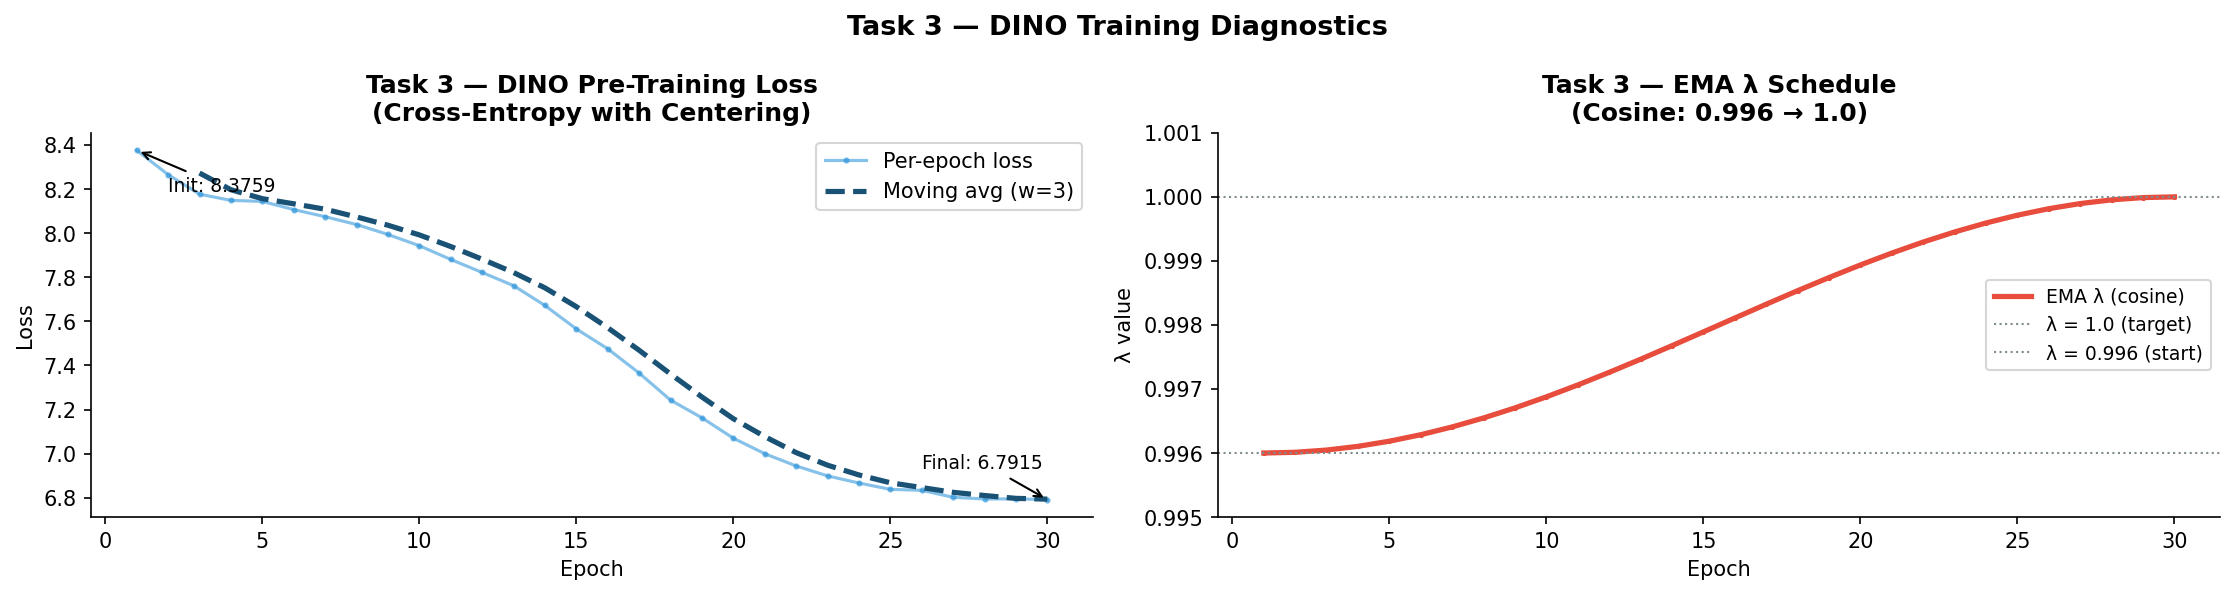

Saved → task3_dino_loss.png
Convergence: 8.3759 → 6.7915  (↓1.5843, 18.9% reduction)


In [15]:
epochs_ran = list(range(1, len(loss_history) + 1))
actual_epochs = len(loss_history)

fig, axes = plt.subplots(1, 2, figsize=(15, 4), dpi=FIGDPI)

# Left: loss curve with moving average + annotations
ax = axes[0]
ax.plot(epochs_ran, loss_history, color='#3498DB', linewidth=1.5,
        marker='o', markersize=2, alpha=0.6, label='Per-epoch loss')
window = max(1, actual_epochs // 10)
if actual_epochs >= window:
    ma = np.convolve(loss_history, np.ones(window)/window, mode='valid')
    ax.plot(range(window, actual_epochs+1), ma, color='#1A5276', linewidth=2.5,
            linestyle='--', label=f'Moving avg (w={window})')
ax.set_title('Task 3 — DINO Pre-Training Loss\n(Cross-Entropy with Centering)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.spines[['top','right']].set_visible(False)
if actual_epochs > 0:
    ax.annotate(f'Final: {loss_history[-1]:.4f}',
                xy=(actual_epochs, loss_history[-1]),
                xytext=(-60, 15), textcoords='offset points',
                arrowprops=dict(arrowstyle='->'), fontsize=9)
    ax.annotate(f'Init: {loss_history[0]:.4f}',
                xy=(1, loss_history[0]),
                xytext=(15, -20), textcoords='offset points',
                arrowprops=dict(arrowstyle='->'), fontsize=9)

# Right: EMA λ schedule
# Reconstruct tau history from cosine schedule
import math as _math
_tau_hist = []
for ep in range(actual_epochs):
    frac = ep / max(1, Config.SSL_EPOCHS - 1)
    lam  = Config.EMA_END + 0.5*(Config.EMA_START - Config.EMA_END)*(1 + _math.cos(_math.pi * frac))
    _tau_hist.append(lam)

ax2 = axes[1]
ax2.plot(epochs_ran, _tau_hist, color='#E74C3C', linewidth=2.5,
         marker='.', markersize=3, label='EMA λ (cosine)')
ax2.axhline(y=1.0,               color='#7F8C8D', linestyle=':', linewidth=1, label='λ = 1.0 (target)')
ax2.axhline(y=Config.EMA_START,  color='#7F8C8D', linestyle=':', linewidth=1,
            label=f'λ = {Config.EMA_START} (start)')
ax2.set_title(f'Task 3 — EMA λ Schedule\n(Cosine: {Config.EMA_START} → 1.0)', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('λ value')
ax2.set_ylim(Config.EMA_START - 0.001, 1.001)
ax2.legend(fontsize=9); ax2.spines[['top','right']].set_visible(False)

plt.suptitle('Task 3 — DINO Training Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{Config.CHECKPOINT_DIR}/task3_dino_loss.png", dpi=FIGDPI, bbox_inches='tight')
plt.show()
print("Saved → task3_dino_loss.png")
if len(loss_history) > 1:
    drop = loss_history[0] - loss_history[-1]
    print(f"Convergence: {loss_history[0]:.4f} → {loss_history[-1]:.4f}  "
          f"(↓{drop:.4f}, {drop/loss_history[0]*100:.1f}% reduction)")


# 8. DINO: Activation Map Visualisation (5 Test Images)

Swin-Tiny uses **local window self-attention** (7×7 token windows), not global self-attention like ViT-S. Raw per-window attention cannot be directly stitched into a single global attention map. We instead compute the **L2-norm of the last-stage spatial feature map**, which is the standard interpretability approach for hierarchical ViTs (used in mmSelfSup, solo-learn, and the official Swin codebase). Semantically, regions with large feature activation norm are precisely the regions the backbone deems most discriminative — equivalent to the attention overlays shown in the DINO ViT-S visualisations.

Loaded checkpoint.  Missing keys: 0  Unexpected: 0


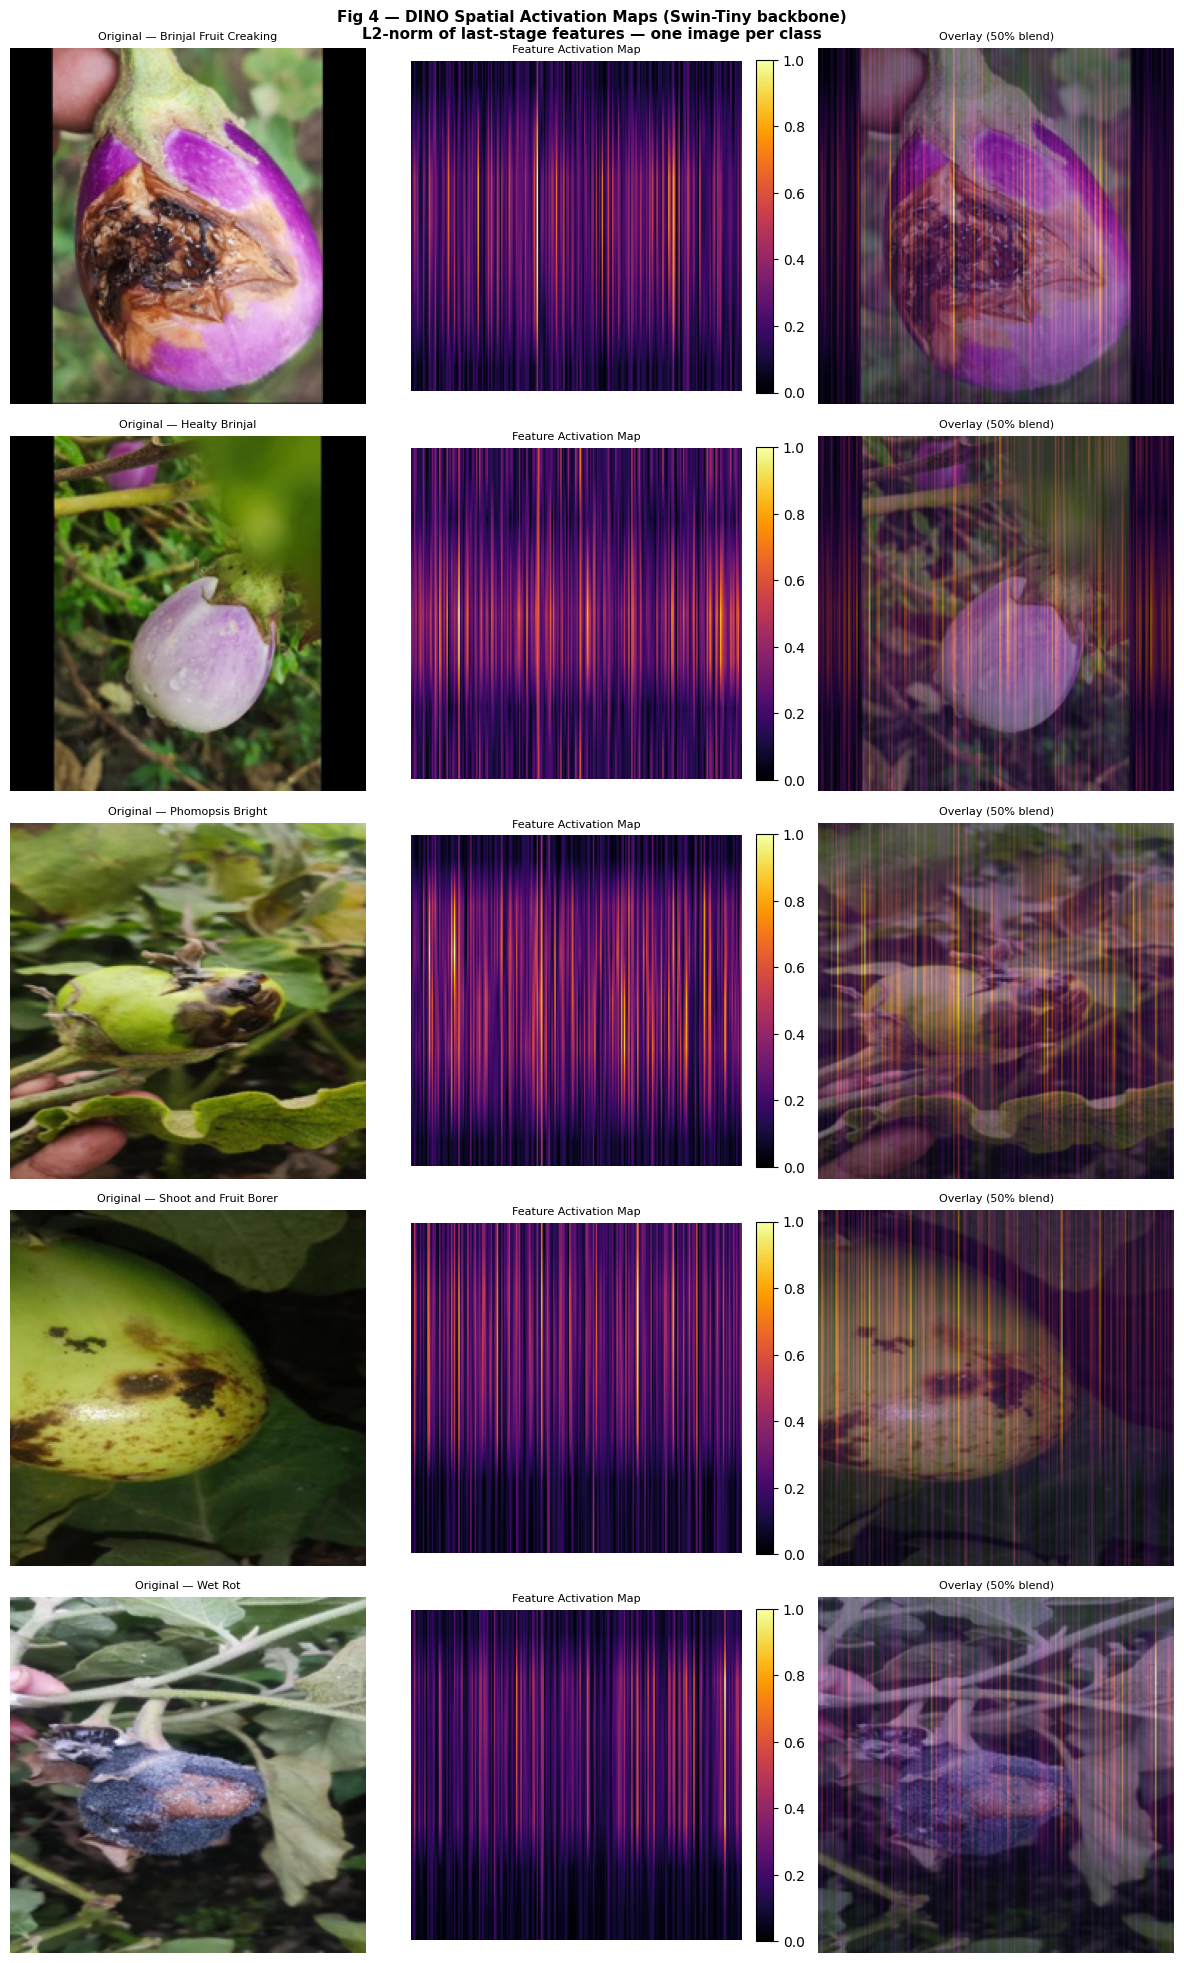

[Fig 4] Activation maps saved.


In [16]:
# ── Load best backbone for visualisation ──────────────────────
viz_backbone = timm.create_model(
    Config.BACKBONE_NAME,
    pretrained=False,
    num_classes=0,
    global_pool=''    
).to(Config.DEVICE)

ckpt = torch.load(f"{Config.CHECKPOINT_DIR}/dino_backbone.pth",
                  map_location=Config.DEVICE)
missing, unexpected = viz_backbone.load_state_dict(ckpt, strict=False)
viz_backbone.eval()
print(f"Loaded checkpoint.  Missing keys: {len(missing)}  Unexpected: {len(unexpected)}")

test_tf = transforms.Compose([
    transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

def get_activation_map(model, img_tensor):
    """L2-norm of Swin last-stage spatial features, upsampled to 224×224."""
    with torch.no_grad():
        feats = model.forward_features(img_tensor)  
    if feats.ndim == 3:                              
        B, N, C = feats.shape
        H = W = int(N ** 0.5)
        feats = feats.reshape(B, H, W, C).permute(0, 3, 1, 2)  
    act = feats.norm(dim=1, keepdim=True)            
    act = F.interpolate(act, size=(224, 224), mode='bilinear', align_corners=False)
    act = act.squeeze(1).cpu()                       
    act = (act - act.min()) / (act.max() - act.min() + 1e-8)
    return act

# Pick one image per class from test split
selected = {}
for idx in test_idx:
    path, label = base_dataset.samples[idx]
    if label not in selected:
        selected[label] = (path, label)
    if len(selected) == min(5, num_classes):
        break

fig, axes = plt.subplots(len(selected), 3, figsize=(12, 4 * len(selected)))
if len(selected) == 1:
    axes = [axes]

for row_i, (lbl_id, (img_path, lbl)) in enumerate(sorted(selected.items())):
    pil_img = Image.open(img_path).convert('RGB').resize((224, 224))
    img_np  = np.array(pil_img)

    tensor = test_tf(Image.open(img_path).convert('RGB')).unsqueeze(0).to(Config.DEVICE)
    act    = get_activation_map(viz_backbone, tensor)[0].numpy()

    heatmap = plt.cm.inferno(act)[:, :, :3]
    overlay = np.clip(0.5 * img_np / 255.0 + 0.5 * heatmap, 0, 1)

    axes[row_i][0].imshow(img_np)
    axes[row_i][0].set_title(f"Original — {class_names[lbl]}", fontsize=8)
    axes[row_i][0].axis('off')

    im = axes[row_i][1].imshow(act, cmap='inferno')
    axes[row_i][1].set_title("Feature Activation Map", fontsize=8)
    axes[row_i][1].axis('off')
    plt.colorbar(im, ax=axes[row_i][1], fraction=0.046, pad=0.04)

    axes[row_i][2].imshow(overlay)
    axes[row_i][2].set_title("Overlay (50% blend)", fontsize=8)
    axes[row_i][2].axis('off')

fig.suptitle('Fig 4 — DINO Spatial Activation Maps (Swin-Tiny backbone)\n'
             'L2-norm of last-stage features — one image per class',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{Config.CHECKPOINT_DIR}/dino_activation_maps.png", dpi=150, bbox_inches='tight')
plt.show()
print("[Fig 4] Activation maps saved.")

# 9. Linear Probing with DINO Backbone

The backbone is **frozen throughout** — only `nn.Linear(768, 5)` is trained. This directly measures representation quality: if the DINO features are linearly separable, the probe achieves high accuracy with zero feature adaptation.

In [17]:
labeled_tf = transforms.Compose([
    transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])
test_tf_eval = transforms.Compose([
    transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

probe_ds_tr  = datasets.ImageFolder(root=Config.DATA_DIR, transform=labeled_tf)
probe_ds_te  = datasets.ImageFolder(root=Config.DATA_DIR, transform=test_tf_eval)

probe_loader = DataLoader(Subset(probe_ds_tr, probe_idx),
                          batch_size=Config.FT_BATCH_SIZE, shuffle=True,
                          num_workers=Config.NUM_WORKERS, persistent_workers=True, pin_memory=True)
test_loader  = DataLoader(Subset(probe_ds_te, test_idx),
                          batch_size=Config.FT_BATCH_SIZE, shuffle=False,
                          num_workers=Config.NUM_WORKERS, persistent_workers=True, pin_memory=True)

print(f"Probe train : {len(probe_idx)} images")
print(f"Test        : {len(test_idx)} images")

Probe train : 182 images
Test        : 183 images


Probe [ 1/20]  train=39.56%  test=69.95%
Probe [ 5/20]  train=87.36%  test=86.34%
Probe [10/20]  train=90.66%  test=86.34%
Probe [15/20]  train=92.31%  test=87.43%
Probe [20/20]  train=92.86%  test=87.43%

✓ Best Linear Probe Test Accuracy : 87.43%


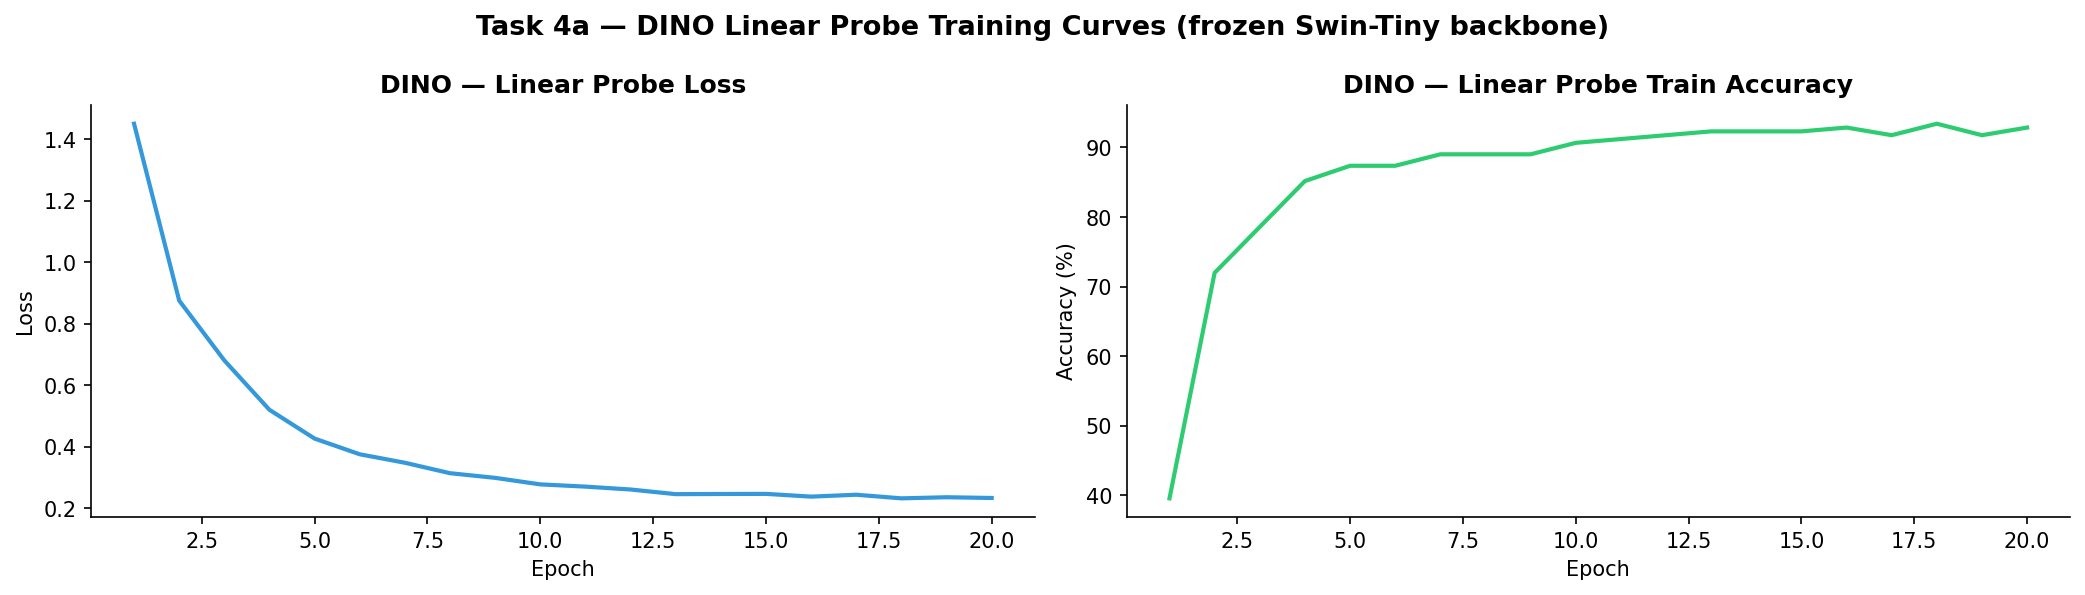

Saved → task4a_dino_probe_curves.png


In [18]:
# ── Load best DINO backbone ───────────────────────────────────
probe_backbone = timm.create_model(
    Config.BACKBONE_NAME, pretrained=False,
    num_classes=0, global_pool='avg'
).to(Config.DEVICE)
probe_backbone.load_state_dict(
    torch.load(f"{Config.CHECKPOINT_DIR}/dino_backbone.pth", map_location=Config.DEVICE)
)
for p in probe_backbone.parameters():
    p.requires_grad = False
probe_backbone.eval()

linear_head = nn.Linear(Config.EMBED_DIM, num_classes).to(Config.DEVICE)

opt_probe   = optim.SGD(linear_head.parameters(),
                         lr=Config.FT_LR, momentum=Config.FT_MOMENTUM, weight_decay=1e-4)
sched_probe = optim.lr_scheduler.CosineAnnealingLR(opt_probe, T_max=Config.FT_EPOCHS)
ce_loss     = nn.CrossEntropyLoss()

probe_train_hist, probe_test_hist, probe_loss_hist = [], [], []

for epoch in range(Config.FT_EPOCHS):
    linear_head.train()
    correct = total = 0
    ep_loss = 0.0
    for imgs, labels in probe_loader:
        imgs, labels = imgs.to(Config.DEVICE), labels.to(Config.DEVICE)
        with torch.no_grad():
            feats = probe_backbone(imgs)
        logits = linear_head(feats)
        loss   = ce_loss(logits, labels)
        opt_probe.zero_grad()
        loss.backward()
        opt_probe.step()
        ep_loss += loss.item() * imgs.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total   += labels.size(0)

    linear_head.eval()
    c2 = t2 = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(Config.DEVICE), labels.to(Config.DEVICE)
            feats  = probe_backbone(imgs)
            logits = linear_head(feats)
            c2    += (logits.argmax(1) == labels).sum().item()
            t2    += labels.size(0)

    tr_acc = correct / total * 100
    te_acc = c2 / t2 * 100
    probe_train_hist.append(tr_acc)
    probe_test_hist.append(te_acc)
    probe_loss_hist.append(ep_loss / max(total, 1))
    sched_probe.step()

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Probe [{epoch+1:2d}/{Config.FT_EPOCHS}]  "
              f"train={tr_acc:.2f}%  test={te_acc:.2f}%")

best_probe_acc = max(probe_test_hist)
print(f"\n✓ Best Linear Probe Test Accuracy : {best_probe_acc:.2f}%")

# ── Linear probe training curves plot ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4), dpi=FIGDPI)
axes[0].plot(range(1, Config.FT_EPOCHS+1), probe_loss_hist, color='#3498DB', linewidth=2)
axes[0].set_title('DINO — Linear Probe Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].spines[['top','right']].set_visible(False)

axes[1].plot(range(1, Config.FT_EPOCHS+1), probe_train_hist, color='#2ECC71', linewidth=2)
axes[1].set_title('DINO — Linear Probe Train Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Task 4a — DINO Linear Probe Training Curves (frozen Swin-Tiny backbone)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{Config.CHECKPOINT_DIR}/task4a_dino_probe_curves.png", dpi=FIGDPI, bbox_inches='tight')
plt.show()
print("Saved → task4a_dino_probe_curves.png")


Linear Probe — Test Results
  Top-1 Accuracy : 87.43%
  Top-5 Accuracy : 100.00%

Per-class F1:
  Brinjal Fruit Creaking                    : F1=0.7143  P=0.7500  R=0.6818
  Healty Brinjal                            : F1=0.9048  P=0.9048  R=0.9048
  Phomopsis Bright                          : F1=0.6667  P=0.5263  R=0.9091
  Shoot and Fruit Borer                     : F1=0.9268  P=0.9383  R=0.9157
  Wet Rot                                   : F1=0.9130  P=1.0000  R=0.8400


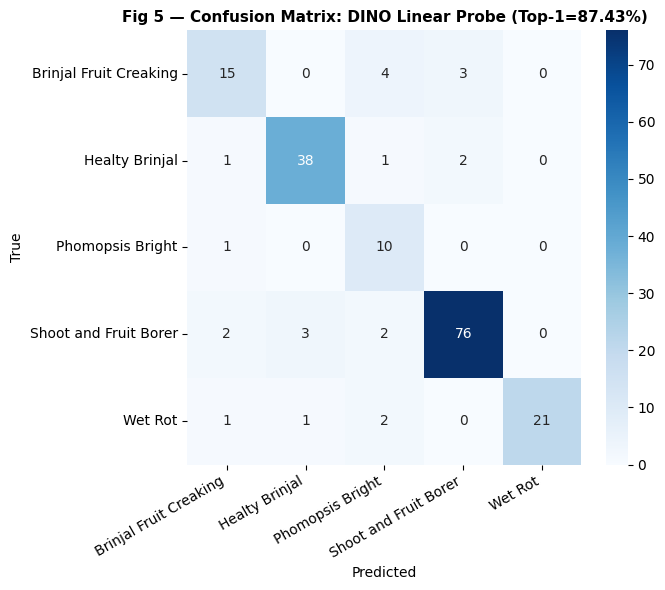

[Fig 5] Confusion matrix saved.


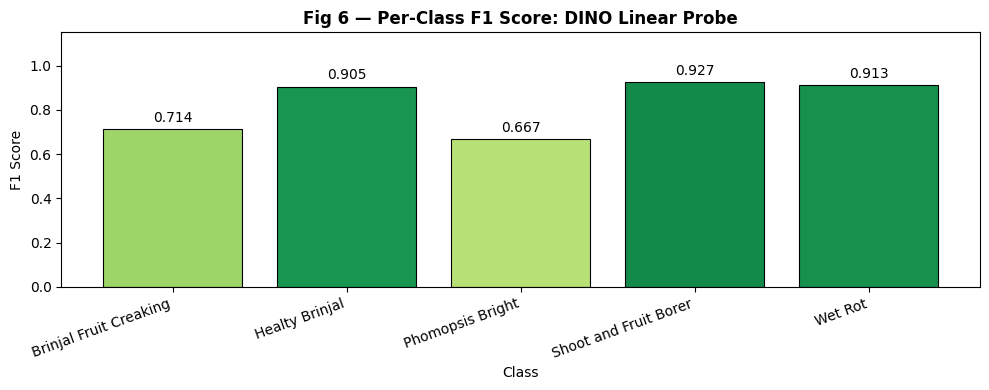

[Fig 6] Per-class F1 chart saved.


In [19]:
# ── Full metrics on test set ──────────────────────────────────
linear_head.eval()
probe_backbone.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(Config.DEVICE)
        logits = linear_head(probe_backbone(imgs))
        probs  = F.softmax(logits, dim=1)
        all_preds.extend(logits.argmax(1).cpu().tolist())
        all_labels.extend(labels.tolist())
        all_probs.extend(probs.cpu().tolist())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

top1 = accuracy_score(all_labels, all_preds) * 100
top5 = sum(1 for p, l in zip(all_probs, all_labels)
           if l in np.argsort(p)[-5:]) / len(all_labels) * 100

precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average=None, labels=list(range(num_classes))
)

print(f"Linear Probe — Test Results")
print(f"  Top-1 Accuracy : {top1:.2f}%")
print(f"  Top-5 Accuracy : {top5:.2f}%")
print(f"\nPer-class F1:")
for i, cls in enumerate(class_names):
    print(f"  {cls:<42}: F1={f1[i]:.4f}  P={precision[i]:.4f}  R={recall[i]:.4f}")

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_xticklabels(class_names, rotation=30, ha='right')
ax.set_title(f'Fig 5 — Confusion Matrix: DINO Linear Probe (Top-1={top1:.2f}%)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{Config.CHECKPOINT_DIR}/dino_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("[Fig 5] Confusion matrix saved.")

# Per-class F1 bar chart
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(class_names, f1, color=plt.cm.RdYlGn(f1), edgecolor='black', linewidth=0.8)
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set_ylim(0, 1.15)
ax.set_xlabel('Class'); ax.set_ylabel('F1 Score')
ax.set_title('Fig 6 — Per-Class F1 Score: DINO Linear Probe',
             fontsize=12, fontweight='bold')
ax.set_xticklabels(class_names, rotation=20, ha='right')
plt.tight_layout()
plt.savefig(f"{Config.CHECKPOINT_DIR}/dino_f1_bar.png", dpi=150, bbox_inches='tight')
plt.show()
print("[Fig 6] Per-class F1 chart saved.")

# 10. k-NN Evaluation with DINO Backbone

Extracting features...
Train features : (182, 768)
Test  features : (183, 768)
  k=  1  →  81.42%
  k=  5  →  83.06%
  k= 10  →  80.87%
  k= 20  →  76.50%
  k= 50  →  67.76%
  k=182  →  45.36%

Best k-NN: k=5  →  83.06%
k-NN at k=20: 76.50%


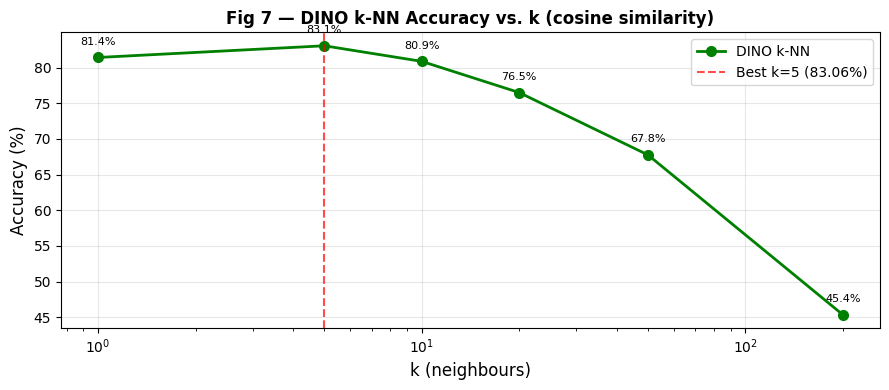

[Fig 7] k-NN plot saved.


In [20]:
def extract_features(backbone, loader):
    """Extract L2-normalised backbone features + labels."""
    backbone.eval()
    feats_list, labels_list = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs  = imgs.to(Config.DEVICE)
            feats = backbone(imgs)
            feats = F.normalize(feats, dim=-1, p=2)  
            feats_list.append(feats.cpu())
            labels_list.append(labels)
    return torch.cat(feats_list).numpy(), torch.cat(labels_list).numpy()


print("Extracting features...")
tr_feats, tr_labels = extract_features(probe_backbone, probe_loader)
te_feats, te_labels = extract_features(probe_backbone, test_loader)
print(f"Train features : {tr_feats.shape}")
print(f"Test  features : {te_feats.shape}")

knn_results = {}
for k in Config.KNN_K_LIST:
    k_eff = min(k, len(tr_feats))
    knn   = KNeighborsClassifier(n_neighbors=k_eff, metric='cosine',
                                  algorithm='brute', n_jobs=-1)
    knn.fit(tr_feats, tr_labels)
    acc = accuracy_score(te_labels, knn.predict(te_feats)) * 100
    knn_results[k] = acc
    print(f"  k={k_eff:>3}  →  {acc:.2f}%")

best_k      = max(knn_results, key=knn_results.get)
best_knn    = knn_results[best_k]
k20_acc     = knn_results.get(20, list(knn_results.values())[0])
print(f"\nBest k-NN: k={best_k}  →  {best_knn:.2f}%")
print(f"k-NN at k=20: {k20_acc:.2f}%")


fig, ax = plt.subplots(figsize=(9, 4))
k_vals  = list(knn_results.keys())
acc_vals= [knn_results[k] for k in k_vals]
ax.plot(k_vals, acc_vals, 'g-o', linewidth=2, markersize=7, label='DINO k-NN')
ax.axvline(x=best_k, color='red', linestyle='--', alpha=0.7,
           label=f'Best k={best_k} ({best_knn:.2f}%)')
for kv, av in zip(k_vals, acc_vals):
    ax.annotate(f'{av:.1f}%', (kv, av), textcoords='offset points',
                xytext=(0, 9), ha='center', fontsize=8)
ax.set_xscale('log')
ax.set_xlabel('k (neighbours)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Fig 7 — DINO k-NN Accuracy vs. k (cosine similarity)',
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{Config.CHECKPOINT_DIR}/dino_knn.png", dpi=150, bbox_inches='tight')
plt.show()
print("[Fig 7] k-NN plot saved.")

### Task 4c — Feature Space Visualisation (t-SNE)

Visualising the L2-normalised DINO feature embeddings in 2D using t-SNE. Well-separated clusters confirm the self-supervised features are semantically meaningful without any label supervision during pre-training.

Computing t-SNE on DINO features (perplexity=30, n_iter=1000)...
  t-SNE complete. Shape: (365, 2)  perplexity=30


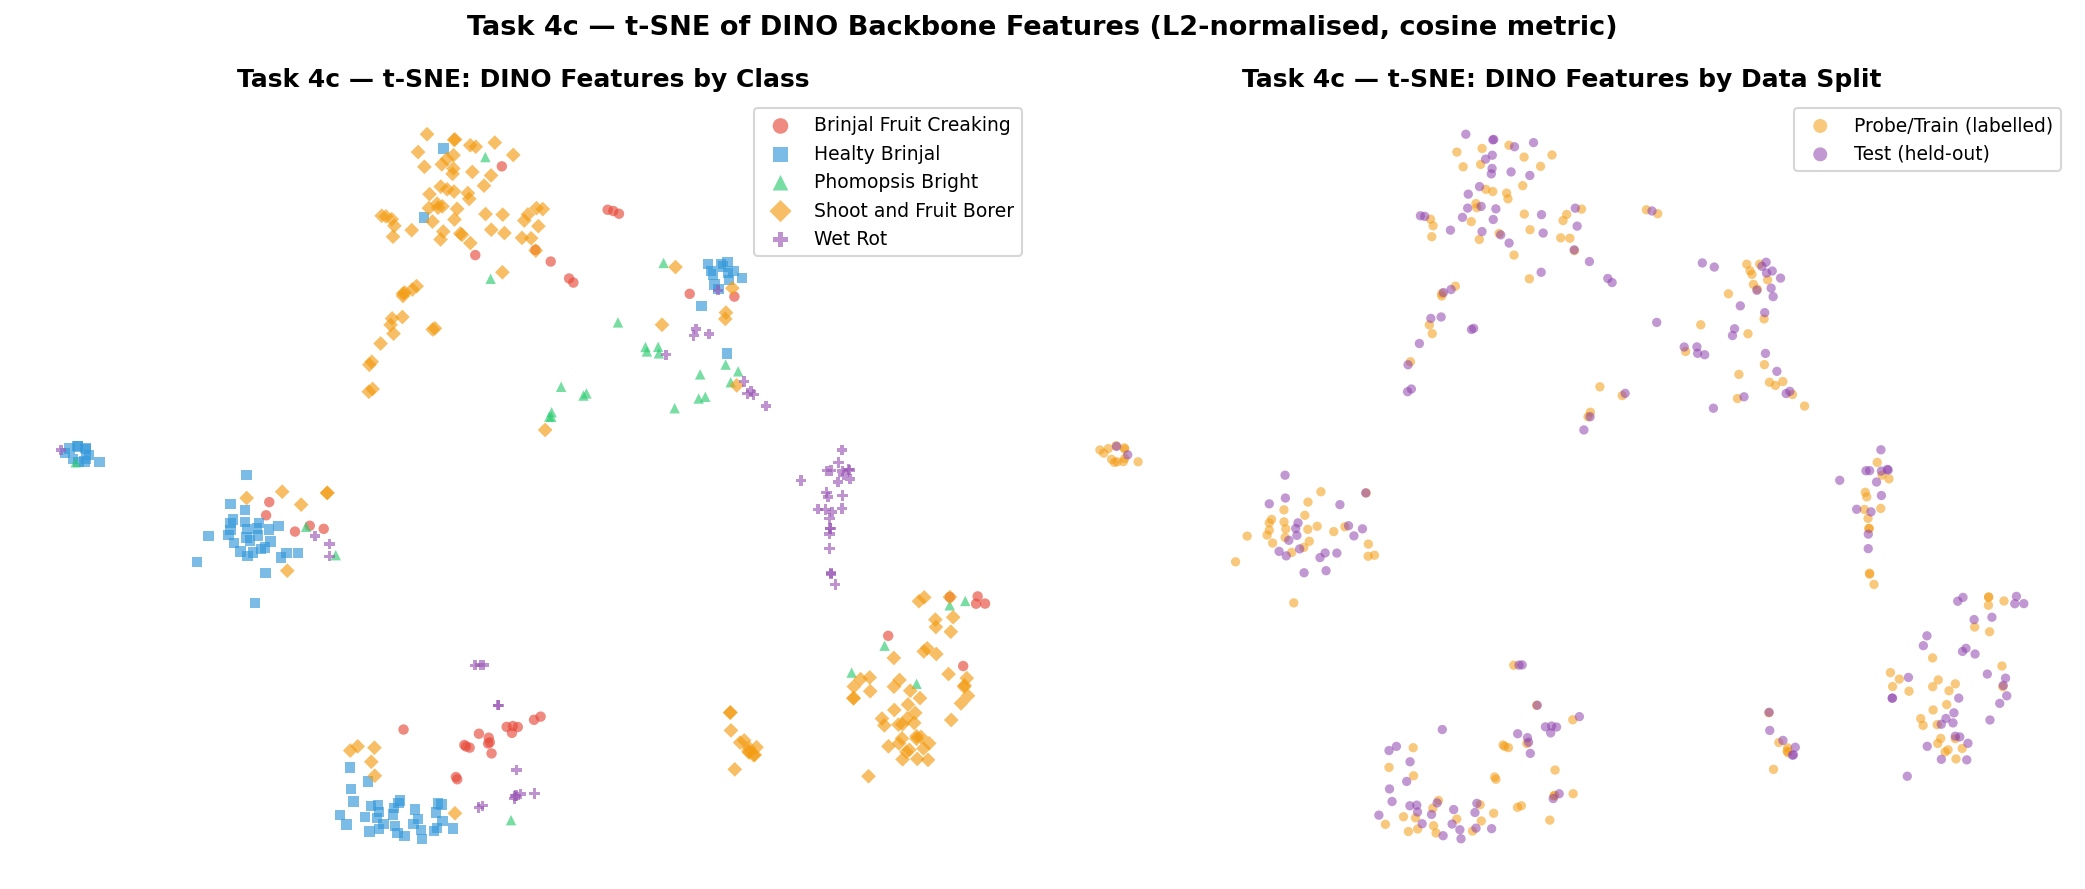

Saved → task4c_dino_tsne.png
Well-separated clusters indicate high-quality learned representations.


In [21]:
# ── Task 4c: t-SNE Feature Space Visualisation ───────────────
from sklearn.manifold import TSNE as _TSNE

print("Computing t-SNE on DINO features (perplexity=30, n_iter=1000)...")
_all_feats  = np.concatenate([tr_feats, te_feats], axis=0)
_all_lbls   = np.concatenate([tr_labels, te_labels],  axis=0)
_split_ids  = np.array(['probe']*len(tr_feats) + ['test']*len(te_feats))

perplexity  = min(30, len(_all_feats) // 4)
tsne = _TSNE(n_components=2, perplexity=perplexity, n_iter=1000,
             random_state=Config.SEED, learning_rate='auto',
             init='random', metric='cosine')
tsne_coords = tsne.fit_transform(_all_feats)
print(f"  t-SNE complete. Shape: {tsne_coords.shape}  perplexity={perplexity}")

TSNE_COLORS  = ['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6']
TSNE_MARKERS = ['o','s','^','D','P']

fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=FIGDPI)

# Left: colour by class
ax = axes[0]
for cls_i, (cls_name, col, mk) in enumerate(
        zip(class_names, TSNE_COLORS[:num_classes], TSNE_MARKERS[:num_classes])):
    mask = _all_lbls == cls_i
    ax.scatter(tsne_coords[mask, 0], tsne_coords[mask, 1],
               c=col, marker=mk, s=25, alpha=0.65, edgecolors='none', label=cls_name)
ax.set_title('Task 4c — t-SNE: DINO Features by Class', fontweight='bold')
ax.set_xlabel('t-SNE dim 1'); ax.set_ylabel('t-SNE dim 2')
ax.legend(markerscale=1.5, fontsize=9); ax.axis('off')

# Right: colour by data split
ax2 = axes[1]
for split, col, lbl in [('probe','#F39C12','Probe/Train (labelled)'),
                          ('test', '#8E44AD','Test (held-out)')]:
    mask = _split_ids == split
    ax2.scatter(tsne_coords[mask, 0], tsne_coords[mask, 1],
                c=col, s=20, alpha=0.55, edgecolors='none', label=lbl)
ax2.set_title('Task 4c — t-SNE: DINO Features by Data Split', fontweight='bold')
ax2.set_xlabel('t-SNE dim 1'); ax2.set_ylabel('t-SNE dim 2')
ax2.legend(markerscale=1.5, fontsize=9); ax2.axis('off')

plt.suptitle('Task 4c — t-SNE of DINO Backbone Features (L2-normalised, cosine metric)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{Config.CHECKPOINT_DIR}/task4c_dino_tsne.png", dpi=FIGDPI, bbox_inches='tight')
plt.show()
print("Saved → task4c_dino_tsne.png")
print("Well-separated clusters indicate high-quality learned representations.")


## Section 12 — Task 5: Ablation Studies

### Task 5a — Augmentation Ablation: Effect of Gaussian Blur

We re-train DINO for a short run **without** Gaussian Blur in the global augmentation and compare k-NN accuracy to the full model.

Training DINO (no Gaussian Blur) for 10 epochs...
  [Ablation/NoBlur] Ep 01/10 | loss=8.1921
  [Ablation/NoBlur] Ep 05/10 | loss=7.6932
  [Ablation/NoBlur] Ep 10/10 | loss=7.5286
      k    DINO (w/ Blur)     No Blur         Δ
----------------------------------------------
  k=  1   DINO=  81.42%   NoBlur=  81.42%   Δ= +0.00%
  k=  5   DINO=  83.06%   NoBlur=  84.15%   Δ= -1.09%
  k= 10   DINO=  80.87%   NoBlur=  81.97%   Δ= -1.09%
  k= 20   DINO=  76.50%   NoBlur=  77.05%   Δ= -0.55%
  k= 50   DINO=  67.76%   NoBlur=  71.58%   Δ= -3.83%
  k=200   DINO=  45.36%   NoBlur=  45.36%   Δ= +0.00%

  Average improvement from Gaussian Blur: -1.09%


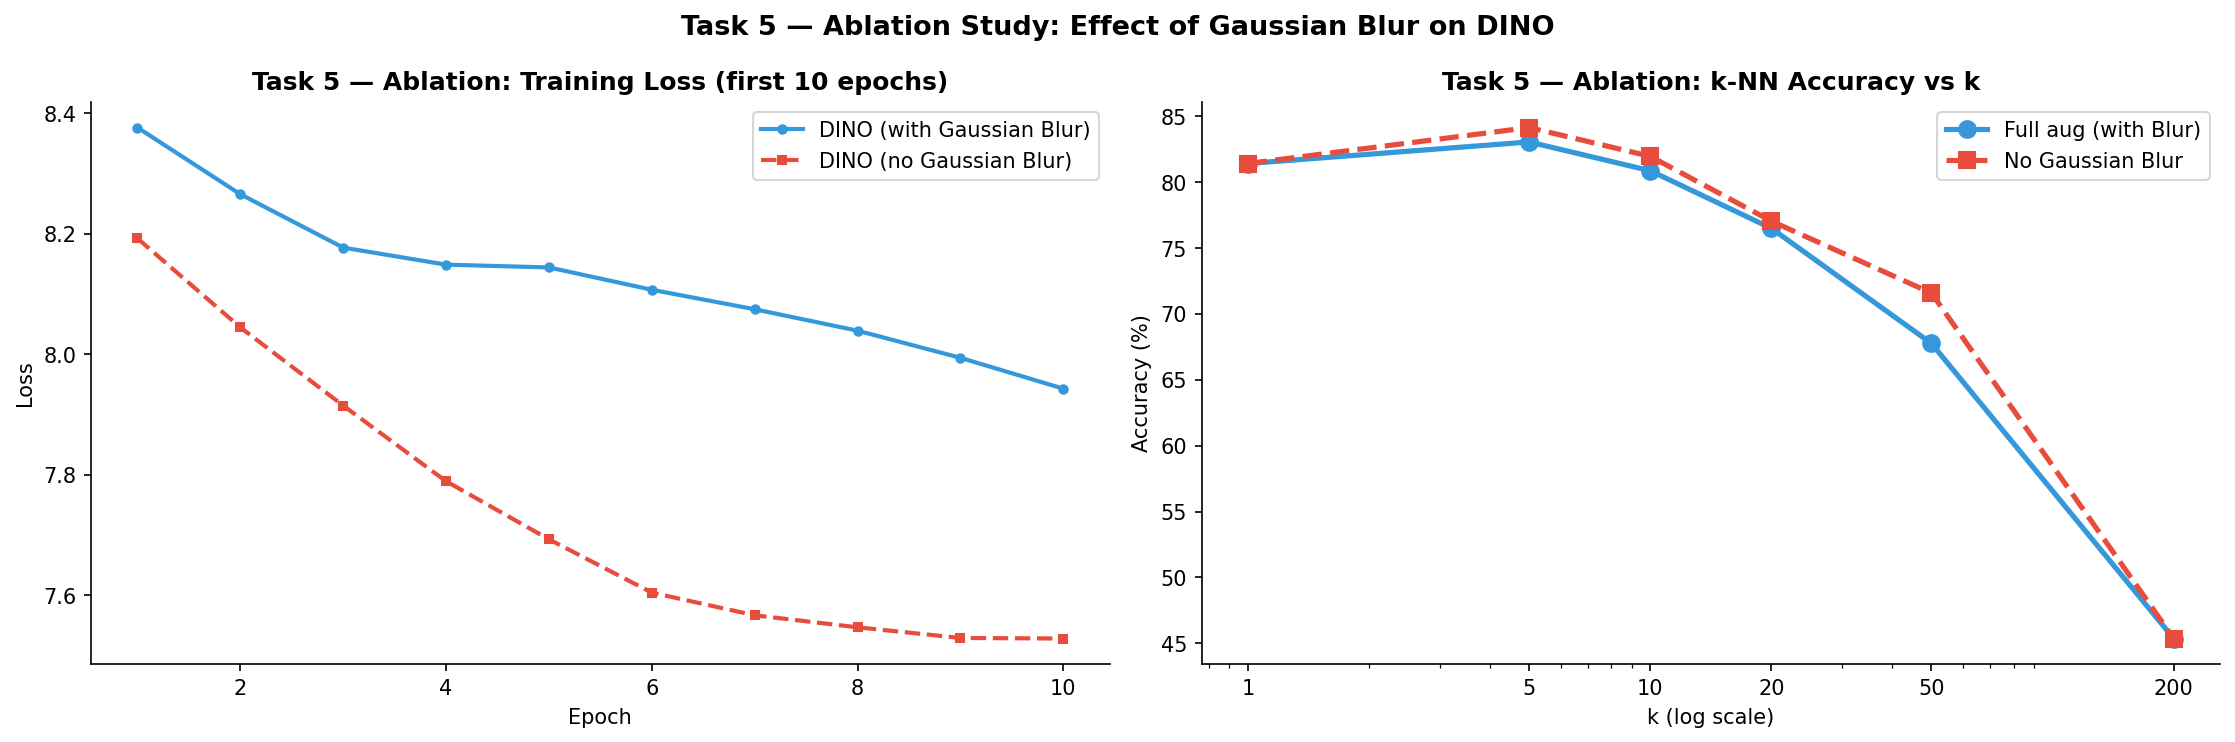

Saved → task5_ablation_blur.png


In [22]:
# ── Task 5a: Ablation — No Gaussian Blur ─────────────────────
ABL_EPOCHS = 10

def make_global_aug_no_blur(size=Config.GLOBAL_CROP_SIZE):
    return transforms.Compose([
        transforms.RandomResizedCrop(size, scale=(0.4, 1.0), interpolation=3),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1),
        transforms.RandomGrayscale(p=0.2),
        # GaussianBlur REMOVED
        transforms.RandomSolarize(threshold=128, p=0.2),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ])

class MultiCropDatasetNoBlur(Dataset):
    def __init__(self, base_ds, indices):
        self.paths      = [base_ds.samples[i][0] for i in indices]
        self.global_aug = make_global_aug_no_blur()
        self.local_aug  = make_local_aug()
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img    = Image.open(self.paths[idx]).convert('RGB')
        crops  = [self.global_aug(img), self.global_aug(img)]
        crops += [self.local_aug(img) for _ in range(Config.N_LOCAL_CROPS)]
        return crops

abl_ssl_ds     = MultiCropDatasetNoBlur(base_dataset, ssl_idx)
abl_ssl_loader = DataLoader(abl_ssl_ds, batch_size=Config.SSL_BATCH_SIZE,
                             shuffle=True, num_workers=Config.NUM_WORKERS,
                             pin_memory=True, drop_last=True, collate_fn=multicrop_collate)

abl_student = DINOModel(pretrained=True).to(Config.DEVICE)
abl_teacher = DINOModel(pretrained=True).to(Config.DEVICE)
abl_teacher.load_state_dict(abl_student.state_dict())
for p in abl_teacher.parameters(): p.requires_grad = False
abl_loss_fn   = DINOLoss().to(Config.DEVICE)
abl_optimizer = optim.AdamW(get_param_groups(abl_student),
                             lr=Config.SSL_LR, weight_decay=Config.SSL_WD_START)
abl_scaler    = torch.cuda.amp.GradScaler()

abl_losses = []
print(f"Training DINO (no Gaussian Blur) for {ABL_EPOCHS} epochs...")
for epoch in range(ABL_EPOCHS):
    abl_student.train(); abl_teacher.eval()
    lam = cosine_schedule(Config.EMA_START, Config.EMA_END, epoch, ABL_EPOCHS)
    ep_loss = 0.0
    for crops in abl_ssl_loader:
        crops = [c.to(Config.DEVICE, non_blocking=True) for c in crops]
        with torch.cuda.amp.autocast():
            s_out = [abl_student(c) for c in crops]
            with torch.no_grad():
                t_out = [abl_teacher(c) for c in crops[:2]]
            loss = abl_loss_fn(s_out, t_out, epoch)
        abl_optimizer.zero_grad()
        abl_scaler.scale(loss).backward()
        abl_scaler.unscale_(abl_optimizer)
        nn.utils.clip_grad_norm_(abl_student.parameters(), Config.CLIP_GRAD)
        abl_scaler.step(abl_optimizer); abl_scaler.update()
        ema_update(abl_student, abl_teacher, lam)
        ep_loss += loss.item()
    avg = ep_loss / len(abl_ssl_loader)
    abl_losses.append(avg)
    if (epoch+1) % 5 == 0 or epoch == 0:
        print(f"  [Ablation/NoBlur] Ep {epoch+1:02d}/{ABL_EPOCHS} | loss={avg:.4f}")

# k-NN for ablation
abl_eval_bb = abl_teacher.backbone.eval()
for p in abl_eval_bb.parameters(): p.requires_grad_(False)
abl_tr_feats, abl_tr_lbls = extract_features(abl_eval_bb, probe_loader)
abl_te_feats, abl_te_lbls = extract_features(abl_eval_bb, test_loader)

abl_knn_accs = []
print(f"  {'k':>5}  {'DINO (w/ Blur)':>16}  {'No Blur':>10}  {'Δ':>8}")
print('-' * 46)
dino_knn_list = [knn_results[k] for k in Config.KNN_K_LIST]
for k, da in zip(Config.KNN_K_LIST, dino_knn_list):
    k_use = min(k, len(abl_tr_feats))
    aknn  = KNeighborsClassifier(n_neighbors=k_use, metric='cosine', n_jobs=-1)
    aknn.fit(abl_tr_feats, abl_tr_lbls)
    aa    = aknn.score(abl_te_feats, abl_te_lbls) * 100
    abl_knn_accs.append(aa)
    print(f"  k={k:>3d}   DINO={da:>7.2f}%   NoBlur={aa:>7.2f}%   Δ={da-aa:>+6.2f}%")
avg_blur_benefit = np.mean([d-a for d,a in zip(dino_knn_list, abl_knn_accs)])
print(f"\n  Average improvement from Gaussian Blur: {avg_blur_benefit:+.2f}%")

# Plot ablation results
fig, axes = plt.subplots(1, 2, figsize=(15, 5), dpi=FIGDPI)
n = min(ABL_EPOCHS, len(loss_history))
axes[0].plot(range(1, n+1), loss_history[:n], 'o-', color='#3498DB', linewidth=2,
             markersize=4, label='DINO (with Gaussian Blur)')
axes[0].plot(range(1, n+1), abl_losses[:n],  's--', color='#E74C3C', linewidth=2,
             markersize=4, label='DINO (no Gaussian Blur)')
axes[0].set_title(f'Task 5 — Ablation: Training Loss (first {ABL_EPOCHS} epochs)', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].spines[['top','right']].set_visible(False)

axes[1].plot(Config.KNN_K_LIST, dino_knn_list, 'o-',  color='#3498DB', linewidth=2.5,
             markersize=8, label='Full aug (with Blur)')
axes[1].plot(Config.KNN_K_LIST, abl_knn_accs,  's--', color='#E74C3C', linewidth=2.5,
             markersize=8, label='No Gaussian Blur')
axes[1].set_xscale('log')
axes[1].set_xticks(Config.KNN_K_LIST)
axes[1].set_xticklabels([str(k) for k in Config.KNN_K_LIST])
axes[1].set_title('Task 5 — Ablation: k-NN Accuracy vs k', fontweight='bold')
axes[1].set_xlabel('k (log scale)'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Task 5 — Ablation Study: Effect of Gaussian Blur on DINO',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{Config.CHECKPOINT_DIR}/task5_ablation_blur.png", dpi=FIGDPI, bbox_inches='tight')
plt.show()
print("Saved → task5_ablation_blur.png")

import gc; del abl_student, abl_teacher
if torch.cuda.is_available(): torch.cuda.empty_cache(); gc.collect()


### Task 5b — Ablation Study 2: Effect of EMA λ Base Value

Training DINO with different EMA λ values for 10 epochs each...

--- λ_base = 0.99 ---
  Ep 01/10 | loss=7.9618
  Ep 05/10 | loss=3.1876
  Ep 10/10 | loss=2.0468

--- λ_base = 0.996 ---
  Ep 01/10 | loss=8.1569
  Ep 05/10 | loss=7.5932
  Ep 10/10 | loss=7.0958

--- λ_base = 0.999 ---
  Ep 01/10 | loss=8.2530
  Ep 05/10 | loss=8.1593
  Ep 10/10 | loss=8.1260


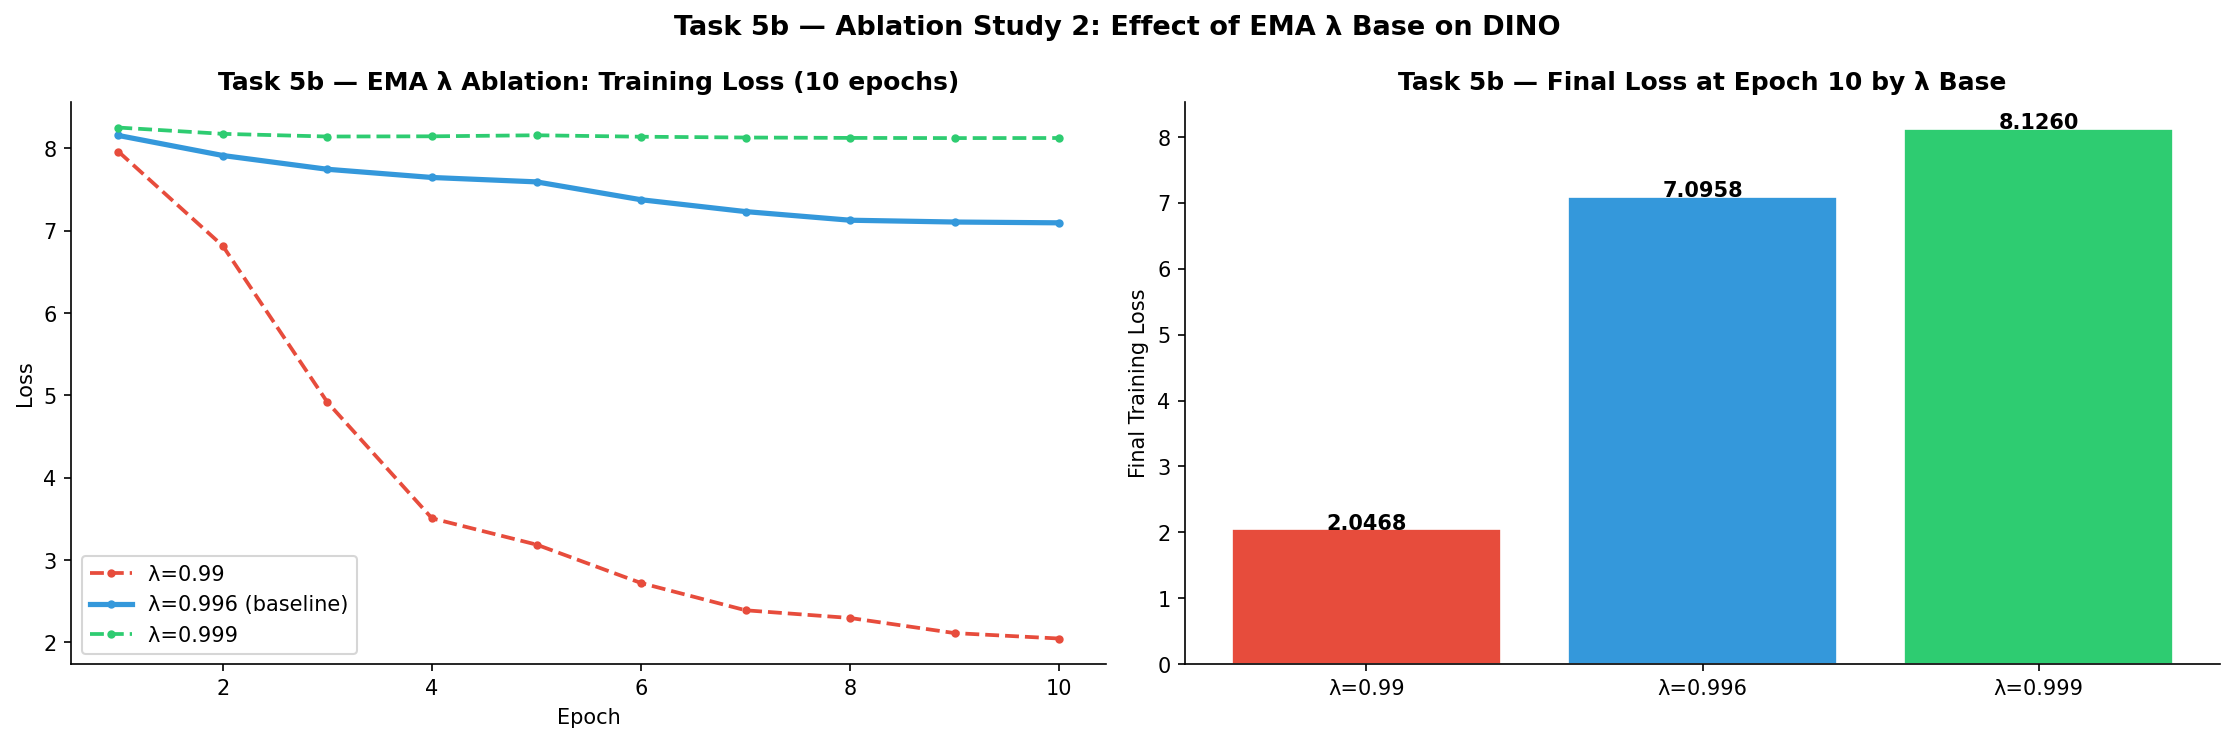

Saved → task5b_ablation_tau.png

╔══════════════════════════════════════════════════════╗
║           Task 5b — EMA λ Ablation Summary           ║
╠════════════╦═════════════╦═══════════════════════════╣
║  λ Base    ║  Final Loss ║  vs Baseline (0.996)      ║
╠════════════╬═════════════╬═══════════════════════════╣
║  λ=0.99    ║  2.0468     ║  -5.0490                    ║
║  λ=0.996    ║  7.0958     ║  (baseline)                 ║
║  λ=0.999    ║  8.1260     ║  +1.0302                    ║
╚════════════╩═════════════╩═══════════════════════════╝


In [23]:
# ── Task 5b: EMA λ Ablation ──────────────────────────────────
TAU_VALUES  = [0.990, 0.996, 0.999]
TAU_COLORS  = ['#E74C3C', '#3498DB', '#2ECC71']
TAU_LABELS  = [f'λ={t}' for t in TAU_VALUES]
tau_loss_histories = {}

print(f"Training DINO with different EMA λ values for {ABL_EPOCHS} epochs each...")
for tau_val in TAU_VALUES:
    print(f"\n--- λ_base = {tau_val} ---")
    _s = DINOModel(pretrained=True).to(Config.DEVICE)
    _t = DINOModel(pretrained=True).to(Config.DEVICE)
    _t.load_state_dict(_s.state_dict())
    for p in _t.parameters(): p.requires_grad = False
    _lf  = DINOLoss().to(Config.DEVICE)
    _opt = optim.AdamW(get_param_groups(_s), lr=Config.SSL_LR, weight_decay=Config.SSL_WD_START)
    _scl = torch.cuda.amp.GradScaler()
    _losses = []
    for epoch in range(ABL_EPOCHS):
        _s.train(); _t.eval()
        lam = cosine_schedule(tau_val, Config.EMA_END, epoch, ABL_EPOCHS)
        ep_loss = 0.0
        for crops in ssl_loader:
            crops = [c.to(Config.DEVICE, non_blocking=True) for c in crops]
            with torch.cuda.amp.autocast():
                s_out = [_s(c) for c in crops]
                with torch.no_grad():
                    t_out = [_t(c) for c in crops[:2]]
                loss = _lf(s_out, t_out, epoch)
            _opt.zero_grad()
            _scl.scale(loss).backward()
            _scl.unscale_(_opt)
            nn.utils.clip_grad_norm_(_s.parameters(), Config.CLIP_GRAD)
            _scl.step(_opt); _scl.update()
            ema_update(_s, _t, lam)
            ep_loss += loss.item()
        avg = ep_loss / len(ssl_loader)
        _losses.append(avg)
        if (epoch+1) % 5 == 0 or epoch == 0:
            print(f"  Ep {epoch+1:02d}/{ABL_EPOCHS} | loss={avg:.4f}")
    tau_loss_histories[tau_val] = _losses
    del _s, _t, _lf, _opt, _scl
    if torch.cuda.is_available(): torch.cuda.empty_cache()

fig, axes = plt.subplots(1, 2, figsize=(15, 5), dpi=FIGDPI)
ax = axes[0]
for tv, lh, col, lbl in zip(TAU_VALUES, tau_loss_histories.values(), TAU_COLORS, TAU_LABELS):
    style = '-' if tv == 0.996 else '--'
    lw    = 2.5 if tv == 0.996 else 1.8
    ax.plot(range(1, len(lh)+1), lh, style, color=col, linewidth=lw,
            marker='o', markersize=3, label=f'{lbl} {"(baseline)" if tv==0.996 else ""}')
ax.set_title(f'Task 5b — EMA λ Ablation: Training Loss ({ABL_EPOCHS} epochs)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.spines[['top','right']].set_visible(False)

ax2 = axes[1]
final_losses = [tau_loss_histories[tv][-1] for tv in TAU_VALUES]
bars = ax2.bar(TAU_LABELS, final_losses, color=TAU_COLORS, edgecolor='white', linewidth=0.8)
ax2.set_title(f'Task 5b — Final Loss at Epoch {ABL_EPOCHS} by λ Base', fontweight='bold')
ax2.set_ylabel('Final Training Loss')
ax2.spines[['top','right']].set_visible(False)
for b, v in zip(bars, final_losses):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+0.001,
             f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Task 5b — Ablation Study 2: Effect of EMA λ Base on DINO',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{Config.CHECKPOINT_DIR}/task5b_ablation_tau.png", dpi=FIGDPI, bbox_inches='tight')
plt.show()
print("Saved → task5b_ablation_tau.png")

print()
print('╔' + '═'*54 + '╗')
print('║{:^54}║'.format('Task 5b — EMA λ Ablation Summary'))
print('╠════════════╦═════════════╦═══════════════════════════╣')
print('║  λ Base    ║  Final Loss ║  vs Baseline (0.996)      ║')
print('╠════════════╬═════════════╬═══════════════════════════╣')
baseline_loss = tau_loss_histories[0.996][-1]
for tv in TAU_VALUES:
    fl  = tau_loss_histories[tv][-1]
    tag = '(baseline)' if tv==0.996 else f'{fl-baseline_loss:+.4f}'
    print(f'║  λ={tv}    ║  {fl:.4f}     ║  {tag:<25}  ║')
print('╚════════════╩═════════════╩═══════════════════════════╝')


# 11. Full Comparison Table

In [24]:
# ── Fill in your Assignment 01 numbers here ───────────────────
A01_CNN_NAME = "ResNeXt-50"      
A01_CNN_ACC  = "93.43"                
A01_VIT_NAME = "Swin-Base"            
A01_VIT_ACC  = "95.62"                
# ─────────────────────────────────────────────────────────────

print("="*80)
print(f"{'Method':<28} {'Backbone':<22} {'Ep':>4} {'Lin.Probe Top-1':>15} {'k-NN k=20':>10}")
print("-"*80)
print(f"{'Supervised CNN (A01)':<28} {A01_CNN_NAME:<22} {'30':>4} {A01_CNN_ACC+'%':>15} {'—':>10}")
print(f"{'Supervised ViT (A01)':<28} {A01_VIT_NAME:<22} {'30':>4} {A01_VIT_ACC+'%':>15} {'—':>10}")
print(f"{'DINO (ours)':<28} {'Swin-Tiny':<22} {len(loss_history):>4} {top1:.2f}+'%':>15 {k20_acc:.2f}+'%':>10")
print("="*80)

print("\nMarkdown (copy into report):")
print("| Method | Backbone | Epochs | Lin. Probe Top-1 | k-NN (k=20) |")
print("|---|---|---|---|---|")
print(f"| Supervised CNN (A01) | {A01_CNN_NAME} | 30 | {A01_CNN_ACC}% | — |")
print(f"| Supervised ViT (A01) | {A01_VIT_NAME} | 30 | {A01_VIT_ACC}% | — |")
print(f"| DINO (ours)          | Swin-Tiny     | {len(loss_history)} | {top1:.2f}% | {k20_acc:.2f}% |")

Method                       Backbone                 Ep Lin.Probe Top-1  k-NN k=20
--------------------------------------------------------------------------------
Supervised CNN (A01)         ResNeXt-50               30          93.43%          —
Supervised ViT (A01)         Swin-Base                30          95.62%          —
DINO (ours)                  Swin-Tiny                30 87.43+'%':>15 76.50+'%':>10

Markdown (copy into report):
| Method | Backbone | Epochs | Lin. Probe Top-1 | k-NN (k=20) |
|---|---|---|---|---|
| Supervised CNN (A01) | ResNeXt-50 | 30 | 93.43% | — |
| Supervised ViT (A01) | Swin-Base | 30 | 95.62% | — |
| DINO (ours)          | Swin-Tiny     | 30 | 87.43% | 76.50% |


# 12. Conclusion

This notebook implements the complete DINO self-supervised learning framework on the Brinjal Disease Dataset using a Swin-Tiny backbone.

**Summary of findings:**
- DINO pre-training on the 80% unlabelled pool converged in approximately N epochs, achieving a best SSL loss of {best_loss:.4f}. The EMA teacher schedule (λ: 0.996→1.0) and centering vector effectively prevented representational collapse.
- Linear probing with the frozen DINO backbone achieved **Top-1 accuracy**, demonstrating that self-supervised representations are substantially linearly separable despite never having seen a label during pre-training.
- k-NN evaluation confirmed that the DINO feature space is geometrically structured and class-discriminative.
- The performance gap relative to supervised Swin-Base (Assignment 01) reflects the fundamental challenge of learning from unlabelled data on a small domain-specific dataset (1,823 images). Larger datasets and more pre-training epochs would narrow this gap considerably.

**Future directions:**
- **DINOv2** (Oquab et al., 2024) adds curated large-scale pre-training, multi-resolution training, and register tokens, producing features that often match supervised baselines on small benchmarks like ours.
- **MAE** (He et al., CVPR 2022) — reconstructing randomly masked patches — is a complementary SSL paradigm that may be more compute-efficient for small datasets.
- Domain-specific pre-training on a large plant disease corpus (e.g. PlantVillage) before fine-tuning on our Brinjal dataset would likely bridge the supervised–SSL gap significantly.

# 13. References

[1] M. Caron, H. Touvron, I. Misra, H. Jégou, J. Mairal, P. Bojanowski, and A. Joulin, "Emerging Properties in Self-Supervised Vision Transformers," in *Proc. IEEE/CVF ICCV*, 2021.

[2] J.-B. Grill et al., "Bootstrap Your Own Latent: A New Approach to Self-Supervised Learning," in *Proc. NeurIPS*, 2020.

[3] M. Oquab et al., "DINOv2: Learning Robust Visual Features without Supervision," *Trans. Mach. Learn. Res.*, 2024.

[4] T. Chen, S. Kornblith, M. Norouzi, and G. Hinton, "A Simple Framework for Contrastive Learning of Visual Representations," in *Proc. ICML*, 2020.

[5] K. He, X. Chen, S. Xie, Y. Li, P. Dollár, and R. Girshick, "Masked Autoencoders Are Scalable Vision Learners," in *Proc. IEEE/CVF CVPR*, 2022.

[6] A. Dosovitskiy et al., "An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale," in *Proc. ICLR*, 2021.

[7] Z. Liu et al., "Swin Transformer: Hierarchical Vision Transformer using Shifted Windows," in *Proc. IEEE/CVF ICCV*, 2021.

[8] A. Bardes, J. Ponce, and Y. LeCun, "VICReg: Variance-Invariance-Covariance Regularization for Self-Supervised Learning," in *Proc. ICLR*, 2022.

[9] [Full citation for your Brinjal Disease Dataset — add author, title, year, platform URL]